# New Model Fitting — Passive Algorithm

---

## Step 1 — Mathematical Problem Statement

**Goal:** define the dataset, the unknowns, the per-datapoint scores, and the four-way preference relation. No optimization yet.

---

### 1.1 Dataset

We have $n$ observed pairwise comparisons. Each datum $i$ consists of:

$$
\mathcal{D} = \{\,(c_i,\, d_i,\, y_i)\,\}_{i=1}^n
$$

where
- $c_i \in \mathbb{R}^m$ — the **signed** feature difference vector,
- $d_i \in \mathbb{R}^m_{\geq 0}$ — the **absolute** feature difference vector,
- $y_i \in \{\succ,\, \prec,\, \sim,\, \bowtie\}$ — the observed label.

For a direct comparison of alternatives $F$ and $F'$ with per-attribute utility values $u_j(\cdot)$:

$$
(c_i)_j = u_j(F) - u_j(F'), \qquad (d_i)_j = |u_j(F) - u_j(F')|.
$$

Note that $d_i \geq 0$ componentwise by construction, and $|(c_i)_j| = (d_i)_j$ elementwise.

---

### 1.2 Unknowns

The model has three unknowns:

$$
\omega \in \Delta^m := \{\omega \in \mathbb{R}^m : \omega_j \geq 0,\; \textstyle\sum_j \omega_j = 1\},
$$
$$
\tau_r \in [0,1], \qquad \tau_\kappa \in [0,1).
$$

$\omega$ are the **attribute weights**, $\tau_r$ is the **indifference threshold**, and $\tau_\kappa \in [0,1)$ is the **conflict half-angle** (it controls the width of the wedge; $\tau_\kappa < 1$ ensures the wedge is proper).

---

### 1.3 Preference intensity and direction

To motivate the scores $r_i$ and $\kappa_i$, first decompose the per-attribute differences into two one-sided components:

$$
s(F,F') := \sum_j \omega_j \bigl(u_j(F) - u_j(F')\bigr)_+, \qquad
s(F',F) := \sum_j \omega_j \bigl(u_j(F') - u_j(F)\bigr)_+,
$$

where $(\cdot)_+ = \max(0,\cdot)$. Thus $s(F,F')$ is the total weighted advantage of $F$ over $F'$, summing only the dimensions where $F$ wins; $s(F',F)$ is the corresponding quantity with roles swapped. Both are non-negative by construction.

Then define:

$$
r(F,F') := s(F,F') + s(F',F), \qquad \kappa(F,F') := s(F,F') - s(F',F).
$$

$r$ is the **total preference intensity** — the total weighted magnitude of all attribute differences. $\kappa$ is the **directional strength** — the net balance favoring $F$ over $F'$.

In terms of the data vectors $c_i$ and $d_i$, these reduce to:

$$
r_i := r(F,F') = \omega^\top d_i \geq 0, \qquad \kappa_i := \kappa(F,F') = \omega^\top c_i \in \mathbb{R}.
$$

Both are **linear in $\omega$** for fixed datum $i$. The decomposition via $s(\cdot,\cdot)$ is useful for geometric intuition (Section 1.5); the $r_i, \kappa_i$ form is used for fitting.

---

### 1.4 The four-way preference relation

Define $F \triangleright F'$ by the following complete, non-overlapping partition of the $(\kappa_i, r_i)$ half-plane ($r_i \geq 0$):

$$
F \triangleright F' = \begin{cases}
\succ & \iff r_i \geq \tau_r \;\land\; \kappa_i > \tau_\kappa\,(r_i - \tau_r) \\[4pt]
\prec & \iff r_i \geq \tau_r \;\land\; \kappa_i < -\tau_\kappa\,(r_i - \tau_r) \\[4pt]
\sim  & \iff r_i < \tau_r \\[4pt]
\bowtie & \iff r_i \geq \tau_r \;\land\; |\kappa_i| \leq \tau_\kappa\,(r_i - \tau_r)
\end{cases}
$$

**Interpretation:**

- **Low preference intensity** ($r_i < \tau_r$): the two alternatives differ so little in aggregate that the respondent is **indifferent** ($\sim$). This is a purely intensity-based condition — the direction of any difference is irrelevant below the threshold.

- **Sufficient intensity, small directional imbalance** ($r_i \geq \tau_r$, $|\kappa_i| \leq \tau_\kappa(r_i - \tau_r)$): the alternatives differ enough to matter, but the differences are spread across attributes that pull in opposite directions. The respondent is **in conflict** ($\bowtie$, incomparability). The allowed imbalance grows with $r_i - \tau_r$: as intensity increases beyond the threshold, a *larger* absolute directional difference is still tolerated within the conflict region.

- **Sufficient intensity, strong directional imbalance** ($r_i \geq \tau_r$, $|\kappa_i| > \tau_\kappa(r_i - \tau_r)$): the directionality of the differences dominates, and the respondent gives a **decisive preference** ($\succ$ or $\prec$).

---

### 1.5 Completeness of the partition (strict vs. weak inequalities)

**Claim:** the four cases in Section 1.4 partition every point $(r_i, \kappa_i)$ with $r_i \geq 0$ into exactly one case.

*Proof.* For $r_i < \tau_r$: only $\sim$ applies. For $r_i = \tau_r$: $\tau_\kappa(r_i - \tau_r) = 0$, so the real line $\kappa_i \in \mathbb{R}$ is partitioned into $\kappa_i > 0$ ($\succ$), $\kappa_i < 0$ ($\prec$), $\kappa_i = 0$ ($\bowtie$). For $r_i > \tau_r$: $\tau_\kappa(r_i-\tau_r) > 0$, and the partition of $\mathbb{R}$ into $(-\infty, -\tau_\kappa(r_i-\tau_r))$, $[-\tau_\kappa(r_i-\tau_r),\, \tau_\kappa(r_i-\tau_r)]$, $(\tau_\kappa(r_i-\tau_r), +\infty)$ is complete. $\square$

**Boundary convention:** strict inequalities on $\succ$ and $\prec$, and weak inequalities on $\bowtie$, place the decisive boundaries themselves into $\bowtie$. This is the natural choice: a point on the wedge boundary is still in the conflict region, not yet decisively outside it.

**Note for fitting:** strict inequalities become weak when written as LP constraints (feasibility does not distinguish open from closed). For the purposes of the fitting algorithm, all decisive conditions are treated as non-strict: $\kappa_i \geq \tau_\kappa(r_i - \tau_r)$ for $\succ$, etc.

---

### 1.6 Label constraints in terms of the data vectors

Substituting $r_i = \omega^\top d_i$ and $\kappa_i = \omega^\top c_i$, the partition conditions become:

| Label $y_i$ | Constraint on $(\omega, \tau_r, \tau_\kappa)$ for datum $(c_i, d_i)$ |
|---|---|
| $\succ$ | $\omega^\top d_i \geq \tau_r$ and $\omega^\top c_i \geq \tau_\kappa\,(\omega^\top d_i - \tau_r)$ |
| $\prec$ | $\omega^\top d_i \geq \tau_r$ and $-\omega^\top c_i \geq \tau_\kappa\,(\omega^\top d_i - \tau_r)$ |
| $\sim$ | $\omega^\top d_i < \tau_r$ |
| $\bowtie$ | $\omega^\top d_i \geq \tau_r$ and $|\omega^\top c_i| \leq \tau_\kappa\,(\omega^\top d_i - \tau_r)$ |

Expanded without absolute values (treating boundary as $\geq$ for LP):

$$
y_i = {\succ}: \quad
\omega^\top d_i \geq \tau_r, \qquad
\omega^\top c_i - \tau_\kappa\,\omega^\top d_i \geq -\tau_\kappa\,\tau_r
$$
$$
y_i = {\prec}: \quad
\omega^\top d_i \geq \tau_r, \qquad
-\omega^\top c_i - \tau_\kappa\,\omega^\top d_i \geq -\tau_\kappa\,\tau_r
$$
$$
y_i = {\sim}: \quad \omega^\top d_i \leq \tau_r
$$
$$
y_i = {\bowtie}: \quad
\omega^\top d_i \geq \tau_r, \qquad
\tau_\kappa\,\omega^\top d_i - \omega^\top c_i \geq \tau_\kappa\,\tau_r, \qquad
\tau_\kappa\,\omega^\top d_i + \omega^\top c_i \geq \tau_\kappa\,\tau_r
$$

Define the effective feature vectors $f_i^+ := c_i - \tau_\kappa\,d_i$ and $f_i^- := -c_i - \tau_\kappa\,d_i$. Then for fixed $\tau_\kappa$:

- $\succ$: $\omega^\top d_i \geq \tau_r$ and $\omega^\top f_i^+ \geq -\tau_\kappa\,\tau_r$
- $\prec$: $\omega^\top d_i \geq \tau_r$ and $\omega^\top f_i^- \geq -\tau_\kappa\,\tau_r$
- $\bowtie$: $\omega^\top d_i \geq \tau_r$ and $\omega^\top f_i^+ \leq -\tau_\kappa\,\tau_r$ and $\omega^\top f_i^- \leq -\tau_\kappa\,\tau_r$

All constraints are **linear in $(\omega, \tau_r)$ for fixed $\tau_\kappa$**. This is the key structural fact enabling a linear program.

---

### 1.7 Geometry in the $(s(F,F'),\, s(F',F))$ plane

Let $x = s(F',F) \geq 0$ and $y = s(F,F') \geq 0$. The domain is the non-negative quadrant. Then $r = x + y$ and $\kappa = y - x$.

**Indifference region** ($\sim$): $x + y < \tau_r$ — the open triangle below the anti-diagonal $x + y = \tau_r$.

**The apex of the wedge:** the transition from $\sim$ to the other states begins at $r = \tau_r$, $\kappa = 0$, which in $(x,y)$ coordinates is:

$$
\left(\frac{\tau_r}{2},\; \frac{\tau_r}{2}\right).
$$

This is the point on the anti-diagonal that lies on the main diagonal $y = x$. It is the apex of the conflict wedge.

> **Note on the figure:** if the horizontal axis is $x = s(F',F)$ and the vertical axis is $y = s(F,F')$, the apex label in the figure should be $\bigl(\tfrac{\tau_r}{2}, \tfrac{\tau_r}{2}\bigr)$, **not** $(\tau_r, \tau_r)$.

**Decisive boundaries:** substituting $r = x+y$ and $\kappa = y-x$ into $\kappa = \tau_\kappa(r-\tau_r)$ gives:

$$
y - x = \tau_\kappa(x+y-\tau_r)
\;\implies\;
y = \frac{1+\tau_\kappa}{1-\tau_\kappa}\,x - \frac{\tau_\kappa\,\tau_r}{1-\tau_\kappa}.
$$

This is a line through $\bigl(\tfrac{\tau_r}{2}, \tfrac{\tau_r}{2}\bigr)$ with slope $\frac{1+\tau_\kappa}{1-\tau_\kappa} > 1$ (steeper than the diagonal). Similarly, $\kappa = -\tau_\kappa(r-\tau_r)$ gives:

$$
y = \frac{1-\tau_\kappa}{1+\tau_\kappa}\,x + \frac{\tau_\kappa\,\tau_r}{1+\tau_\kappa},
$$

a line through the same apex with slope $\frac{1-\tau_\kappa}{1+\tau_\kappa} < 1$ (shallower than the diagonal). The four regions are:

| Region | $(x,y)$ condition |
|---|---|
| $\sim$ | $x + y < \tau_r$ |
| $\bowtie$ | $x + y \geq \tau_r$ and between the two boundary lines |
| $\succ$ | above both boundary lines ($y \gg x$; $F$ dominates) |
| $\prec$ | below both boundary lines ($x \gg y$; $F'$ dominates) |

As $\tau_\kappa \to 0$ the two boundary lines collapse to the diagonal $y = x$, and $\bowtie$ degenerates to a ray. As $\tau_\kappa \to 1$ the boundaries become nearly vertical/horizontal, and $\bowtie$ expands to fill almost the entire region above the indifference boundary.

---

### 1.8 Fixes relative to the old formulation

This formulation corrects two inconsistencies present in earlier versions of the model:

1. **Apex mislabeled:** the old formulation's decisive conditions used a constant threshold $\kappa \geq \tau_\kappa$, which in the $(x,y)$ plane gives parallel decision boundaries — lines of slope 1 offset from the diagonal. These are not wedge boundaries and do not meet at a common point. The new formulation places the apex correctly at $\bigl(\tfrac{\tau_r}{2}, \tfrac{\tau_r}{2}\bigr)$, matching the figure.

2. **Gap in the partition:** the old formulation used $\kappa \geq \tau_\kappa$ for decisive conditions but $|\kappa| \leq \tau_\kappa(r - \tau_r)$ for $\bowtie$. These two thresholds coincide only at $r = \tau_r + 1$, creating a gap region for $r \in [\tau_r, \tau_r+1)$ where no label was assigned. The new formulation uses $\tau_\kappa(r - \tau_r)$ consistently for all four conditions, so the decisive boundaries and the $\bowtie$ boundary are the same curve — no gap anywhere.

---

### 1.9 Open question before proceeding

**What labels does the Boerstler data actually contain?**

The `chosen` column appears to be binary (0 or 1), encoding $\succ$ and $\prec$ only. It is not yet clear whether the dataset contains explicit $\sim$ or $\bowtie$ labels, or whether those are simply absent (meaning the respondent always gave a decisive answer, or non-decisive responses were dropped).

This matters: if only $\{\succ, \prec\}$ appear, then $\tau_r$ and $\tau_\kappa$ are not identified from the data alone — the model reduces to a standard weighted linear preference, and any $\tau_r < \min_i r_i$ and $\tau_\kappa = 0$ would fit perfectly. Resolving this is necessary before Step 2.

---

# Observational Equivalence Classes

---

## Step 1 — The observable probability map

**Object being defined:** the map
$$
\Phi: (\omega, \tau_r, \tau_\kappa) \mapsto \bigl(P(Y_i = 1)\bigr)_{i=1}^n \in [0,1]^n.
$$

### 1.1 Setup

Fix a parameter triple $(\omega, \tau_r, \tau_\kappa)$. For datum $i$, compute:
$$
r_i = \omega^\top d_i \geq 0, \qquad \kappa_i = \omega^\top c_i \in \mathbb{R}.
$$

The observation model assigns:
$$
P(Y_i = 1) = \begin{cases}
1 & \text{latent state is } \succ \\
0 & \text{latent state is } \prec \\
\tfrac{1}{2} & \text{latent state is } \sim \text{ or } \bowtie
\end{cases}
$$

### 1.2 Substituting the latent rules

Using the complete partition from Section 1.4 of Step 1:

$$
P(Y_i = 1 \mid \omega, \tau_r, \tau_\kappa)
= \begin{cases}
1 & \text{if } r_i \geq \tau_r \text{ and } \kappa_i > \tau_\kappa(r_i - \tau_r) \\
0 & \text{if } r_i \geq \tau_r \text{ and } \kappa_i < -\tau_\kappa(r_i - \tau_r) \\
\tfrac{1}{2} & \text{if } r_i < \tau_r \quad (\sim) \\
\tfrac{1}{2} & \text{if } r_i \geq \tau_r \text{ and } |\kappa_i| \leq \tau_\kappa(r_i - \tau_r) \quad (\bowtie)
\end{cases}
$$

Since the four-way partition is complete and non-overlapping (proved in Section 1.5 of Step 1), every point falls into exactly one case. There are no gaps or ambiguities.

### 1.3 Simplified form

The two cases producing $\tfrac{1}{2}$ can be merged. Define the **undecided set** for datum $i$:

$$
U_i(\omega, \tau_r, \tau_\kappa) := \bigl\{ r_i < \tau_r \bigr\} \cup \bigl\{ r_i \geq \tau_r \text{ and } |\kappa_i| \leq \tau_\kappa(r_i - \tau_r) \bigr\}.
$$

Then the probability map takes only three values:

$$
\boxed{
P(Y_i = 1) =
\begin{cases}
1 & \text{if } r_i \geq \tau_r \text{ and } \kappa_i > \tau_\kappa(r_i - \tau_r) \\
0 & \text{if } r_i \geq \tau_r \text{ and } \kappa_i < -\tau_\kappa(r_i - \tau_r) \\
\tfrac{1}{2} & \text{if } (i,\omega,\tau_r,\tau_\kappa) \in U_i
\end{cases}
}
$$

### 1.4 What the map actually encodes

$P(Y_i = 1)$ takes values in $\{0, \tfrac{1}{2}, 1\}$ — three points, not a continuum. The entire probability vector $(P(Y_i=1))_{i=1}^n$ is therefore a function $\{1,\ldots,n\} \to \{0,\tfrac{1}{2},1\}$, i.e., it is **equivalent to a partition** of the index set into three disjoint subsets:

$$
\mathcal{I}_1 = \{i : P(Y_i=1)=1\}, \quad
\mathcal{I}_0 = \{i : P(Y_i=1)=0\}, \quad
\mathcal{I}_{1/2} = \{i : P(Y_i=1)=\tfrac{1}{2}\}.
$$

Two parameter triples that induce the same partition induce the same observable distribution on any finite dataset.

---

## Step 2 — The observational equivalence relation

**Object being defined:** a relation $\sim_{obs}$ on the parameter space
$$
\Theta := \Delta^m \times [0,1] \times [0,1).
$$

### 2.1 Definition

Two triples $(\omega, \tau_r, \tau_\kappa)$ and $(\omega', \tau_r', \tau_\kappa')$ are **observationally equivalent on dataset $\mathcal{D}$**, written
$$
(\omega, \tau_r, \tau_\kappa) \sim_{obs} (\omega', \tau_r', \tau_\kappa'),
$$
if and only if
$$
P(Y_i = 1 \mid \omega, \tau_r, \tau_\kappa) = P(Y_i = 1 \mid \omega', \tau_r', \tau_\kappa') \qquad \text{for all } i = 1,\ldots,n.
$$

### 2.2 Equivalent reformulation

Since $P(Y_i = 1)$ takes values in $\{0, \tfrac{1}{2}, 1\}$, this is equivalent to requiring that the two triples induce the **same three-way partition** of $\{1,\ldots,n\}$:
$$
(\omega, \tau_r, \tau_\kappa) \sim_{obs} (\omega', \tau_r', \tau_\kappa')
\iff
(\mathcal{I}_1, \mathcal{I}_0, \mathcal{I}_{1/2}) = (\mathcal{I}_1', \mathcal{I}_0', \mathcal{I}_{1/2}').
$$

This is a well-defined equivalence relation (reflexive, symmetric, transitive by construction).

### 2.3 What this relation does and does not capture

**What is encoded:** for each datum $i$, whether the parameter triple places $(\kappa_i, r_i)$ in the decisive-left region, decisive-right region, or undecided region.

**What is lost:** any distinction *within* $\mathcal{I}_{1/2}$ between $\sim$ and $\bowtie$. Two triples that agree on which data are decisive but disagree on *why* the remaining data are undecided (indifference vs. incomparability) are observationally equivalent. This is the content of Step 4.

### 2.4 A note on the topology of equivalence classes

The number of distinct equivalence classes is at most $3^n$ (one per assignment of each datum to $\{0, \tfrac{1}{2}, 1\}$), but most of these $3^n$ assignments are not achievable by any parameter triple. The achievable ones are constrained by the geometry of the score functions $\kappa_i(\omega)$ and $r_i(\omega)$. Characterizing exactly which partitions are achievable is the task of Step 3.

---

## Step 3 — Characterize the equivalence classes in terms of the dataset features

**Claim:** two parameter triples $(\omega, \tau_r, \tau_\kappa)$ and $(\omega', \tau_r', \tau_\kappa')$ are observationally equivalent on $\mathcal{D}$ if and only if they produce the same partition of $\{1,\ldots,n\}$ into **decisive-left** ($\mathcal{I}_1$), **decisive-right** ($\mathcal{I}_0$), and **pooled undecided** ($\mathcal{I}_{1/2}$).

### 3.1 Proof (both directions)

**($\Rightarrow$) Equivalence implies same partition.**
By definition, equivalence means $P(Y_i=1\mid\omega,\tau_r,\tau_\kappa) = P(Y_i=1\mid\omega',\tau_r',\tau_\kappa')$ for all $i$. Since $P(Y_i=1) \in \{0,\tfrac{1}{2},1\}$, equality of probabilities is the same as agreement on the three-way partition. $\checkmark$

**($\Leftarrow$) Same partition implies equivalence.**
If both triples assign datum $i$ to the same partition cell, then $P(Y_i=1)$ is the same under both (1 for $\mathcal{I}_1$, 0 for $\mathcal{I}_0$, $\tfrac{1}{2}$ for $\mathcal{I}_{1/2}$). Since this holds for every $i$, the triples are equivalent. $\checkmark$

The proof is trivial in both directions because the probability map is a bijection between partition cells and probability values $\{0,\tfrac{1}{2},1\}$. $\square$

### 3.2 Algebraic description of the equivalence class

Fix a realized partition $(\mathcal{I}_1, \mathcal{I}_0, \mathcal{I}_{1/2})$. The equivalence class is the set of all $(\omega', \tau_r', \tau_\kappa') \in \Theta$ satisfying:

$$
\forall\, i \in \mathcal{I}_1: \quad
\omega'^\top d_i \;\ge\; \tau_r'
\quad\text{and}\quad
\omega'^\top c_i \;\ge\; \tau_\kappa'\,(\omega'^\top d_i - \tau_r')
\tag{DL}
$$

$$
\forall\, i \in \mathcal{I}_0: \quad
\omega'^\top d_i \;\ge\; \tau_r'
\quad\text{and}\quad
-\omega'^\top c_i \;\ge\; \tau_\kappa'\,(\omega'^\top d_i - \tau_r')
\tag{DR}
$$

$$
\forall\, i \in \mathcal{I}_{1/2}: \quad
\omega'^\top d_i \;<\; \tau_r'
\;\;\mathbf{or}\;\;
|\omega'^\top c_i| \;\le\; \tau_\kappa'\,(\omega'^\top d_i - \tau_r')
\tag{ND}
$$

together with the domain constraints $\omega' \in \Delta^m$, $\tau_r' \geq 0$, $\tau_\kappa' \in [0,1)$.

**Derivation of (ND):** datum $i$ is undecided iff it is neither decisive-left nor decisive-right. Negating each decisive condition and combining (distributing the NOT over AND as a disjunction):

$$
\neg\bigl[r' \ge \tau_r' \text{ and } \kappa' > \tau_\kappa'(r'-\tau_r')\bigr]
= r' < \tau_r' \text{ or } \kappa' \le \tau_\kappa'(r'-\tau_r')
$$
$$
\neg\bigl[r' \ge \tau_r' \text{ and } \kappa' < -\tau_\kappa'(r'-\tau_r')\bigr]
= r' < \tau_r' \text{ or } \kappa' \ge -\tau_\kappa'(r'-\tau_r')
$$

Taking the AND of these two expressions:

$$
\bigl(r' < \tau_r' \text{ or } \kappa' \le \tau_\kappa'(r'-\tau_r')\bigr)
\;\text{ and }\;
\bigl(r' < \tau_r' \text{ or } \kappa' \ge -\tau_\kappa'(r'-\tau_r')\bigr)
$$

$$
= \;r' < \tau_r' \;\;\mathbf{or}\;\; |\kappa'| \le \tau_\kappa'(r'-\tau_r'). \qquad\checkmark
$$

Note that when $r' < \tau_r'$, the term $\tau_\kappa'(r'-\tau_r') < 0$ and the second disjunct is never satisfied (since $|\kappa'| \geq 0$), so the two disjuncts are mutually exclusive when $r' < \tau_r'$. The condition simplifies correctly.

### 3.3 Linearization for fixed $\tau_\kappa'$

Define the effective feature vectors $f_i^+ := c_i - \tau_\kappa'\,d_i$ and $f_i^- := -c_i - \tau_\kappa'\,d_i$. Then for fixed $\tau_\kappa'$:

- **(DL)** becomes: $\omega'^\top d_i \geq \tau_r'$ and $\omega'^\top f_i^+ \geq -\tau_\kappa'\,\tau_r'$.
- **(DR)** becomes: $\omega'^\top d_i \geq \tau_r'$ and $\omega'^\top f_i^- \geq -\tau_\kappa'\,\tau_r'$.

All (DL) and (DR) constraints are **linear in $(\omega', \tau_r')$** for fixed $\tau_\kappa'$, defining a closed convex polytope $P(\tau_\kappa')$.

- **(ND)** for each $i \in \mathcal{I}_{1/2}$: either $\omega'^\top d_i < \tau_r'$ (datum is $\sim$) or $\omega'^\top f_i^+ \leq -\tau_\kappa'\,\tau_r'$ and $\omega'^\top f_i^- \leq -\tau_\kappa'\,\tau_r'$ (datum is $\bowtie$). This is a disjunction of two convex sets — non-convex in general.

**Consequence:** the equivalence class for fixed $\tau_\kappa'$ is a subset of $P(\tau_\kappa')$ (the decisive constraints) trimmed by the (ND) disjunctions (which rule out reclassifying any undecided datum). Over all $\tau_\kappa' \in [0,1)$, the full equivalence class is $\bigcup_{\tau_\kappa'} [\text{feasible set at } \tau_\kappa']$.

### 3.4 Key structural observation

- The decisive data (DL), (DR) impose **lower-bound constraints** on scores — they pin down which parameter region is consistent with the observed decisive outcomes.
- The undecided data (ND) impose **upper-bound constraints in disjunctive form** — they trim the region by ruling out values that would make any undecided datum decisive.

The equivalence class is the intersection of a polyhedral region (from decisive data) and a union of complements of convex cones (from undecided data).

### 3.5 Boundary of the equivalence class

A parameter triple on the boundary of an equivalence class is one where at least one datum is exactly at a threshold:

- $\omega'^\top d_i = \tau_r'$ for some $i$ (datum on the indifference boundary), or
- $\omega'^\top c_i = \pm\,\tau_\kappa'(\omega'^\top d_i - \tau_r')$ for some $i \in \mathcal{I}_1 \cup \mathcal{I}_0$ (datum on the wedge boundary).

Moving across such a boundary flips one datum's classification, moving to an adjacent equivalence class.

---

## Step 4 — What is lost under the binary observation regime

**The binary observation regime** refers to the setting where $Y_i \in \{0, 1\}$ only — the observer sees each trial as a binary left/right choice, with no explicit signal that a trial was undecided. Under binary observations, both $\sim$ and $\bowtie$ produce $Y_i \in \{0,1\}$ with equal probability (since $P(Y_i=1) = \tfrac{1}{2}$), so they are indistinguishable.

### 4.1 What the observer sees

In a single trial, the observable outcome is $Y_i \in \{0,1\}$. The true generative process is:

$$
Y_i \mid (\omega, \tau_r, \tau_\kappa) \sim \begin{cases} \delta_1 & i \in \mathcal{I}_1 \\ \delta_0 & i \in \mathcal{I}_0 \\ \mathrm{Bernoulli}(\tfrac{1}{2}) & i \in \mathcal{I}_{1/2} \end{cases}
$$

Given enough repeated trials of the same query, one could in principle identify $\mathcal{I}_{1/2}$ (by estimating $P(Y_i=1) \approx \tfrac{1}{2}$), and separately identify $\mathcal{I}_1$ and $\mathcal{I}_0$. So with repeated trials, the three-way partition *is* identifiable from binary observations.

### 4.2 What collapses with a single trial per query

In the typical pairwise-comparison setting, each query $(c_i, d_i)$ is presented **once**. A single observation of $Y_i = 1$ is consistent with both $i \in \mathcal{I}_1$ (deterministic) and $i \in \mathcal{I}_{1/2}$ (random coin). The two cannot be distinguished.

### 4.3 The key collapse: $\sim$ and $\bowtie$ are equivalent

**No binary observation can distinguish $\sim$ from $\bowtie$**, even in repeated trials. Both produce $P(Y_i=1) = \tfrac{1}{2}$. The two states differ in their *reason* for undecidability (total difference too small vs. preferences in conflict), but since both produce the same observable distribution, they are **observationally equivalent under any experiment**. This is a structural non-identification result, not a finite-sample artifact.

### 4.4 What is lost

Under binary observations, the following are **not identified**:

1. **The boundary between $\sim$ and $\bowtie$**: given that datum $i$ is undecided, one cannot determine whether it is undecided because $r_i < \tau_r$ (indifference) or because $r_i \geq \tau_r$ and $|\kappa_i| \leq \tau_\kappa(r_i-\tau_r)$ (conflict).

2. **$\tau_r$ and $\tau_\kappa$ separately** (in general): with no decisive data, any $\tau_r > \max_i r_i$ fits perfectly, regardless of $\tau_\kappa$. With only decisive data, any $\tau_r < \min_i r_i$ and any $\tau_\kappa$ with sufficiently small wedge fits perfectly. The thresholds are only jointly constrained by the mix of decisive and undecided outcomes.

3. **Within-undecided geometry**: two triples that agree on which data are decisive but disagree on the exact split of undecided data into $\sim$ and $\bowtie$ are observationally equivalent.

### 4.5 What *is* identified

Under binary observations with repeated trials:

- The three-way partition $(\mathcal{I}_1, \mathcal{I}_0, \mathcal{I}_{1/2})$ is identified.
- The **decisive cone** in $(\omega, \tau_r, \tau_\kappa)$-space is therefore identified (via the inequalities in Step 3).

The joint $(\omega, \tau_r, \tau_\kappa)$ is not point-identified — the equivalence class can be large — but any point in the class produces the same observable distribution.

---

## Step 5 — Computing the equivalence class of a fitted triple on a finite dataset

Given a fitted triple $(\hat\omega, \hat\tau_r, \hat\tau_\kappa)$ and dataset $\mathcal{D}$, the equivalence class is fully described by the inequalities from Step 3.

### 5.1 Compute the induced partition

For each datum $i$:
1. Compute $\hat{r}_i = \hat\omega^\top d_i$ and $\hat\kappa_i = \hat\omega^\top c_i$.
2. Classify:
   - $i \in \mathcal{I}_1$ if $\hat{r}_i \geq \hat\tau_r$ and $\hat\kappa_i \geq \hat\tau_\kappa(\hat{r}_i - \hat\tau_r)$
   - $i \in \mathcal{I}_0$ if $\hat{r}_i \geq \hat\tau_r$ and $-\hat\kappa_i \geq \hat\tau_\kappa(\hat{r}_i - \hat\tau_r)$
   - $i \in \mathcal{I}_{1/2}$ otherwise

This partition is the **certificate** of the equivalence class.

### 5.2 Write down the inequality system

For a candidate triple $(\omega', \tau_r', \tau_\kappa')$, membership in the same equivalence class requires (for fixed $\tau_\kappa'$):

**From decisive data** (linear in $(\omega', \tau_r')$):
$$
\omega'^\top d_i \geq \tau_r', \quad \omega'^\top f_i^+ \geq -\tau_\kappa'\,\tau_r' \qquad \forall\, i \in \mathcal{I}_1
$$
$$
\omega'^\top d_i \geq \tau_r', \quad \omega'^\top f_i^- \geq -\tau_\kappa'\,\tau_r' \qquad \forall\, i \in \mathcal{I}_0
$$
where $f_i^+ = c_i - \tau_\kappa' d_i$ and $f_i^- = -c_i - \tau_\kappa' d_i$.

**From undecided data** (disjunctive):
$$
\omega'^\top d_i < \tau_r' \;\;\text{or}\;\; |\omega'^\top c_i| \leq \tau_\kappa'(\omega'^\top d_i - \tau_r') \qquad \forall\, i \in \mathcal{I}_{1/2}
$$

**Domain:**
$$
\omega' \geq 0,\quad \mathbf{1}^\top \omega' = 1, \quad \tau_r' \geq 0, \quad \tau_\kappa' \in [0,1).
$$

### 5.3 Practical membership check

Given a candidate triple $(\omega', \tau_r', \tau_\kappa')$, check equivalence with $(\hat\omega, \hat\tau_r, \hat\tau_\kappa)$ as follows:

```python
def same_equivalence_class(omega_hat, tau_r_hat, tau_kappa_hat,
                           omega_new, tau_r_new, tau_kappa_new,
                           c_mat, d_mat):
    """
    c_mat: (n, m) signed difference features
    d_mat: (n, m) absolute difference features
    Returns True if the two triples produce identical partitions.
    """
    for c_i, d_i in zip(c_mat, d_mat):
        r_hat   = omega_hat @ d_i;   kappa_hat   = omega_hat @ c_i
        r_new   = omega_new @ d_i;   kappa_new   = omega_new @ c_i

        wedge_hat = tau_kappa_hat * max(0.0, r_hat - tau_r_hat)
        wedge_new = tau_kappa_new * max(0.0, r_new - tau_r_new)

        left_hat  = (r_hat >= tau_r_hat) and (kappa_hat  >= wedge_hat)
        right_hat = (r_hat >= tau_r_hat) and (-kappa_hat >= wedge_hat)
        left_new  = (r_new >= tau_r_new) and (kappa_new  >= wedge_new)
        right_new = (r_new >= tau_r_new) and (-kappa_new >= wedge_new)

        label_hat = 1 if left_hat else (0 if right_hat else 0.5)
        label_new = 1 if left_new else (0 if right_new else 0.5)

        if label_hat != label_new:
            return False
    return True
```

This runs in $O(nm)$ time and requires no enumeration.

---

## Step 6 — A simple representation of equivalence classes for computation

### 6.1 The canonical representative: the label vector

The simplest complete representation is the **label vector**:

$$
\ell(\omega, \tau_r, \tau_\kappa) := \bigl(\ell_i\bigr)_{i=1}^n, \qquad \ell_i \in \{-1, 0, +1\}
$$

where $+1$ means decisive-left ($\mathcal{I}_1$), $-1$ means decisive-right ($\mathcal{I}_0$), and $0$ means undecided ($\mathcal{I}_{1/2}$).

Two triples are equivalent if and only if their label vectors are identical. The label vector is the canonical representative of the equivalence class.

**Storage:** $n$ integers in $\{-1, 0, +1\}$.

### 6.2 Constraints as a polyhedral description (for fixed $\tau_\kappa'$)

For fixed $\tau_\kappa'$, define $f_i^+ = c_i - \tau_\kappa' d_i$ and $f_i^- = -c_i - \tau_\kappa' d_i$. Let $D^{dec}$ be the matrix with rows $d_i$ for $i \in \mathcal{I}_1 \cup \mathcal{I}_0$, $A^+$ be the matrix with rows $f_i^+$ for $i \in \mathcal{I}_1$, and $A^-$ be the matrix with rows $f_i^-$ for $i \in \mathcal{I}_0$. Then the polytope of parameters consistent with the decisive data is:

$$
P(\tau_\kappa') = \left\{(\omega', \tau_r') \;\middle|\;
\begin{array}{l}
D^{dec}\,\omega' \;\ge\; \tau_r'\,\mathbf{1} \\[2pt]
A^+\,\omega' \;\ge\; -\tau_\kappa'\,\tau_r'\,\mathbf{1} \\[2pt]
A^-\,\omega' \;\ge\; -\tau_\kappa'\,\tau_r'\,\mathbf{1} \\[2pt]
\omega' \ge 0,\;\mathbf{1}^\top\omega' = 1,\;\tau_r' \ge 0
\end{array}
\right\}.
$$

This is a linear feasibility problem in $m+1$ variables ($\omega'$ and $\tau_r'$) with $O(n)$ constraints. The right-hand side constant $-\tau_\kappa'\tau_r'$ shifts the decisive-direction constraints: when $\tau_r' = 0$ (no indifference threshold) the RHS is $0$, recovering the simpler form $A^\pm\omega' \geq 0$.

### 6.3 Recommended representation for the fitting algorithm

Store the equivalence class of a fitted triple as:

1. **Label vector** $\ell \in \{-1, 0, +1\}^n$ — for quick membership testing and logging.
2. **Partition indices** $(\mathcal{I}_1, \mathcal{I}_0, \mathcal{I}_{1/2})$ — for constructing the constraint matrices.
3. **A representative triple** $(\hat\omega, \hat\tau_r, \hat\tau_\kappa)$ — for computing predicted scores on new queries.

The fitting algorithm will represent each candidate solution by its label vector, group candidates by equivalence class, and search within the space of achievable label vectors. This discretization is the key computational benefit of the equivalence class analysis.

### 6.4 How many equivalence classes are there?

An upper bound is $3^n$, but the achievable assignments are constrained by the geometry of the score functions. The decisive-left set $\mathcal{I}_1$ must satisfy $\kappa_i \geq \tau_\kappa(r_i-\tau_r)$ — a linear condition in $\omega$ for fixed $\tau_\kappa$ — and similarly for $\mathcal{I}_0$. The number of achievable partitions equals the number of distinct sign patterns of the pair $(\kappa_i - \tau_\kappa(r_i-\tau_r),\; r_i - \tau_r)$ as $(\omega, \tau_r)$ varies over $\Delta^m \times \mathbb{R}_{\geq 0}$. By VC theory this is at most $O(n^m)$ — polynomial in $n$ for fixed feature dimension $m$.

---

# Fitting Algorithm — Implementation

The following cells implement the fitting algorithm for the new model on the Boerstler data (person 0, 600 trials across 10 sessions).

**Setup:**
- 4 attributes: alcohol (`alco`), depression (`dep`), life expectancy (`life`), crime (`crim`)
- Features: $c_i$ = signed differences (left minus right), $d_i = |c_i|$, normalized so $r_i = \omega^\top d_i \in [0,1]$
- Binary choices: $y_i = 1$ (chose left), $y_i = 0$ (chose right)

**Fitting objective — noisy-decisive likelihood:**

We assume oracle noise at rate $p_{\text{noise}}$: if the person is decisive-left they choose left with probability $1 - p_{\text{noise}}$ (not 1), and the remaining probability $p_{\text{noise}}$ goes to errors. Undecided datums randomize 50/50. The delta log-likelihood relative to the all-undecided baseline is:

$$
\text{score} = n_{dc} \cdot \log(2(1-p)) + n_{de} \cdot \log(2p)
$$

where $n_{dc}$ = decisive-correct, $n_{de}$ = decisive-error, $p = p_{\text{noise}} = 0.10$. Each decisive-correct adds $\approx +0.59$ and each decisive-error subtracts $\approx 1.61$, so the penalty ratio is $C \approx 2.74$: you need roughly 3 correct decisive predictions to justify 1 error.

**Search procedure:**
- Enumerate $\omega$ on the simplex grid with denominator $k=10$ (286 points)
- For each $\omega$, scan all critical $\tau_r$ values (the sorted unique $r_i$ values)
- Scan $\tau_\kappa \in \{0.0, 0.1, \ldots, 0.9\}$
- Return all scored triples, grouped into **equivalence classes** by identical label vector

**Response-alphabet experiments** (later cells):
- **2-response** $\{L, R\}$: score all 600 trials
- **3-response** $\{L, R, \text{slow}\}$: RT > 20s signals undecided ($\sim$ or $\bowtie$); score only fast trials, penalize slow-decisive
- **4-response** $\{L, R, \sim, \bowtie\}$: RT > 20s signals specifically $\bowtie$; penalize slow trials not in the $\bowtie$ zone


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('boerstler_data_labeled.csv', index_col=0)

# Signed differences c_i = u_j(left) - u_j(right), already pre-computed
ATTR       = ['alco', 'dep', 'life', 'crim']
DIFF_COLS  = ['alcodiff', 'depdiff', 'lifediff', 'crimdiff']

# Observed choice: 1 = chose left, 0 = chose right
print("Dataset shape:", df.shape)
print("People:", df['person_id'].nunique())
print()
print("Raw difference ranges:")
for col in DIFF_COLS:
    vals = sorted(df[col].unique())
    print(f"  {col:12s}: {vals}")
print()
print("Choice distribution:", df['chosen'].value_counts().to_dict())

Dataset shape: (12369, 48)
People: 29

Raw difference ranges:
  alcodiff    : [-4, -2, 0, 2, 4]
  depdiff     : [-2, -1, 0, 1, 2]
  lifediff    : [-4, -2, -1, 0, 1, 2, 4]
  crimdiff    : [-2, -1, 0, 1, 2]

Choice distribution: {1: 6246, 0: 6123}


In [38]:
# ── Normalize features ────────────────────────────────────────────────────────
# Divide each attribute's signed difference by its global maximum absolute value
# so that all c_ij ∈ [-1, 1] and d_ij = |c_ij| ∈ [0, 1].
# After normalization, r_i = ω^T d_i ∈ [0, 1] for any ω on the simplex.

RAW_MAX = np.array([
    df['alcodiff'].abs().max(),   # alco: max |diff| = 4
    df['depdiff'].abs().max(),    # dep:  max |diff| = 2
    df['lifediff'].abs().max(),   # life: max |diff| = 4
    df['crimdiff'].abs().max(),   # crim: max |diff| = 2
], dtype=float)

print("Per-attribute normalization divisors:", dict(zip(ATTR, RAW_MAX)))

def get_person_data(person_id, session_id=None):
    """
    Return (c_mat, d_mat, y) for a given person (and optionally session).
    c_mat: (n, 4) normalized signed differences
    d_mat: (n, 4) normalized absolute differences
    y:     (n,)   binary choices, 1=left, 0=right
    """
    mask = df['person_id'] == person_id
    if session_id is not None:
        mask &= df['session_id'] == session_id
    sub = df[mask]
    c = sub[DIFF_COLS].values / RAW_MAX          # signed, normalized
    d = np.abs(c)                                 # absolute, normalized
    y = sub['chosen'].values.astype(int)
    return c, d, y

# Sanity check on person 0
c0, d0, y0 = get_person_data(0)
print(f"\nPerson 0: n={len(y0)} trials, chose_left={y0.sum()}, chose_right={(1-y0).sum()}")
print(f"  r_i range (uniform ω): [{d0.mean(axis=1).min():.3f}, {d0.mean(axis=1).max():.3f}]")
print(f"  κ_i range (uniform ω): [{c0.mean(axis=1).min():.3f}, {c0.mean(axis=1).max():.3f}]")

Per-attribute normalization divisors: {'alco': 4.0, 'dep': 2.0, 'life': 4.0, 'crim': 2.0}

Person 0: n=600 trials, chose_left=297, chose_right=303
  r_i range (uniform ω): [0.062, 1.000]
  κ_i range (uniform ω): [-0.750, 0.875]


In [39]:
# ── Core classification functions ─────────────────────────────────────────────

def classify(omega, tau_r, tau_kappa, c_mat, d_mat):
    """
    Classify each datum into {+1, -1, 0} under the four-way model.

    Uses STRICT inequalities for decisive conditions (κ > wedge),
    so the boundary |κ_i| = wedge correctly belongs to the undecided set (⋈).

    Returns
    -------
    labels : (n,) int8 in {+1, -1, 0}
        +1 = decisive-left,  -1 = decisive-right,  0 = undecided (∼ or ⋈)
    """
    r     = d_mat @ omega                             # (n,) total intensity
    kappa = c_mat @ omega                             # (n,) directional strength
    wedge = tau_kappa * np.maximum(0.0, r - tau_r)   # (n,) half-width of conflict cone

    decisive_left  = (r >= tau_r) & (kappa  > wedge)   # strictly above upper boundary
    decisive_right = (r >= tau_r) & (-kappa > wedge)   # strictly below lower boundary
    # undecided = r < tau_r  OR  |kappa| <= wedge  (~ and ⋈ pooled)

    labels = np.zeros(len(r), dtype=np.int8)
    labels[decisive_left]  =  1
    labels[decisive_right] = -1
    return labels


def count_decisive_correct_error(labels, y):
    """Return (n_decisive_correct, n_decisive_error)."""
    dc = int(np.sum(((labels ==  1) & (y == 1)) | ((labels == -1) & (y == 0))))
    de = int(np.sum(((labels ==  1) & (y == 0)) | ((labels == -1) & (y == 1))))
    return dc, de


def is_feasible(labels, y):
    _, de = count_decisive_correct_error(labels, y)
    return de == 0


def n_decisive(labels):
    return int(np.sum(labels != 0))


# ── Sanity-check the two boundary regimes ─────────────────────────────────────

omega_u = np.ones(4) / 4

# Regime 1: τ_r above the maximum possible r_i (= 1.0) → all datums indifferent
lbl_all_undet = classify(omega_u, tau_r=2.0, tau_kappa=0.0, c_mat=c0, d_mat=d0)
print(f'tau_r=2.0 (above max r_i)  -> decisive: {n_decisive(lbl_all_undet)}  (all indifferent)')

# Regime 2: τ_r=0, τ_κ=0 → no indifference, zero-width wedge → MOST decisive model
# Decisive iff κ_i != 0 exactly.  This is the maximum-decisive regime, not minimum.
lbl_max_dec = classify(omega_u, tau_r=0.0, tau_kappa=0.0, c_mat=c0, d_mat=d0)
kappa_u = c0 @ omega_u
dc, de = count_decisive_correct_error(lbl_max_dec, y0)
print(f'tau_r=0,  tau_k=0          -> decisive: {n_decisive(lbl_max_dec)}, '
      f'boundary (kappa=0): {(kappa_u == 0).sum()}')
print(f'  decisive-correct: {dc}, decisive-error: {de} '
      f'(infeasible — uniform omega makes many errors on 600 trials)')


tau_r=2.0 (above max r_i)  -> decisive: 0  (all indifferent)
tau_r=0,  tau_k=0          -> decisive: 523, boundary (kappa=0): 77
  decisive-correct: 248, decisive-error: 275 (infeasible — uniform omega makes many errors on 600 trials)


In [40]:
# ── Simplex grid ──────────────────────────────────────────────────────────────
# Generate all points on the m-simplex whose weights are multiples of 1/k.
# For m=4, k=10: C(13,3) = 286 points.  k=20: C(23,3) = 1771 points.

def simplex_grid(m, k):
    """
    All points (ω_1,...,ω_m) on the m-simplex with ω_j = n_j/k, n_j ≥ 0, Σn_j = k.
    Returns array of shape (C(m+k-1, m-1), m).
    """
    def _gen(remaining, dims):
        if dims == 1:
            yield (remaining,)
            return
        for v in range(remaining + 1):
            for rest in _gen(remaining - v, dims - 1):
                yield (v,) + rest

    pts = np.array(list(_gen(k, m)), dtype=float) / k
    return pts

omega_grid_10 = simplex_grid(4, k=10)
omega_grid_20 = simplex_grid(4, k=20)
print(f"Simplex grid k=10: {len(omega_grid_10)} points")
print(f"Simplex grid k=20: {len(omega_grid_20)} points")

# Drop the corners (pure single-attribute weights) and edges if desired
# For now keep everything including corners

Simplex grid k=10: 286 points
Simplex grid k=20: 1771 points


In [41]:
# ── Soft-margin fitting ──────────────────────────────────────────────────
#
# Problem: hard feasibility rejects any triple making even one decisive error.
# Human oracle noise (~10-15% for person 0) means a correct model still makes
# errors, so the hard constraint is too strict.
#
# Fix: replace the binary accept/reject with a noisy-decisive likelihood.
# If decisive, oracle is correct with prob (1-p_noise) and errors with p_noise.
# If undecided, oracle randomizes: P(y=1) = 0.5.
#
# Delta log-likelihood vs all-undecided baseline:
#   score = n_dc * log(2*(1-p)) + n_de * log(2*p)
#         = n_dc * A  -  n_de * B
# Each decisive-correct adds A > 0; each decisive-error subtracts B > 0.
# C = B/A is the effective penalty ratio; C=3 corresponds to p_noise ~ 0.1.

def fit_new_model_soft(c_mat, d_mat, y,
                       omega_grid,
                       tau_kappa_vals=np.arange(0, 1.0, 0.1),
                       p_noise=0.1):
    A = np.log(2 * (1 - p_noise))  # reward per decisive-correct (>0)
    B = np.log(2 * p_noise)         # reward per decisive-error   (<0)
    print(f'  p_noise={p_noise:.2f}  C={-B/A:.2f}  (each error cancels {-B/A:.1f} correct datums)')

    n = len(y)
    results = []
    class_summary = {}

    for omega in omega_grid:
        r     = d_mat @ omega
        kappa = c_mat @ omega
        tau_r_candidates = np.concatenate([[0.0], np.sort(np.unique(r))])

        for tau_r in tau_r_candidates:
            for tau_kappa in tau_kappa_vals:
                wedge  = tau_kappa * np.maximum(0.0, r - tau_r)
                left   = (r >= tau_r) & (kappa  > wedge)
                right  = (r >= tau_r) & (-kappa > wedge)

                labels = np.zeros(n, dtype=np.int8)
                labels[left]  =  1
                labels[right] = -1

                dc, de = count_decisive_correct_error(labels, y)
                score  = dc * A + de * B

                rec = dict(omega=omega, tau_r=tau_r, tau_kappa=tau_kappa,
                           n_decisive_correct=dc, n_decisive_error=de,
                           n_decisive=dc+de, n_undecided=n-dc-de,
                           score=score, labels=labels)
                results.append(rec)

                key = labels.tobytes()
                if key not in class_summary:
                    class_summary[key] = dict(labels=labels, dc=dc, de=de,
                                              score=score, triples=[])
                class_summary[key]['triples'].append((omega.copy(), tau_r, tau_kappa))

    results.sort(key=lambda r: -r['score'])
    return results, class_summary


# ── Fit person 0 (all 600 trials) ───────────────────────────────────────
import time
c0, d0, y0 = get_person_data(0)
print(f'Person 0: n={len(y0)}, chose_left={y0.sum()}, chose_right={(1-y0).sum()}')
print()

t0 = time.time()
res_soft, cls_soft = fit_new_model_soft(c0, d0, y0,
                                        omega_grid=omega_grid_10,
                                        tau_kappa_vals=np.arange(0, 1.0, 0.1),
                                        p_noise=0.10)
print(f'Fit done in {time.time()-t0:.1f}s')
print(f'Parameter triples: {len(res_soft)}')
print(f'Distinct equivalence classes: {len(cls_soft)}')

if res_soft:
    best = res_soft[0]
    print(f'\nBest triple:')
    print(f'  omega     = {np.round(best["omega"], 3)}')
    print(f'  tau_r     = {best["tau_r"]:.3f}')
    print(f'  tau_kappa = {best["tau_kappa"]:.1f}')
    print(f'  score     = {best["score"]:.3f}  (vs all-undecided = 0)')
    print(f'  decisive-correct : {best["n_decisive_correct"]}')
    print(f'  decisive-error   : {best["n_decisive_error"]}')
    print(f'  undecided        : {best["n_undecided"]}')


Person 0: n=600, chose_left=297, chose_right=303

  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
Fit done in 3.3s
Parameter triples: 66600
Distinct equivalence classes: 30855

Best triple:
  omega     = [0.3 0.  0.1 0.6]
  tau_r     = 0.475
  tau_kappa = 0.8
  score     = 56.482  (vs all-undecided = 0)
  decisive-correct : 233
  decisive-error   : 50
  undecided        : 317


Best triple (soft, p_noise=0.10):
  omega=[0.3 0.  0.1 0.6], tau_r=0.475, tau_kappa=0.8
  dc=233, de=50, undecided=317


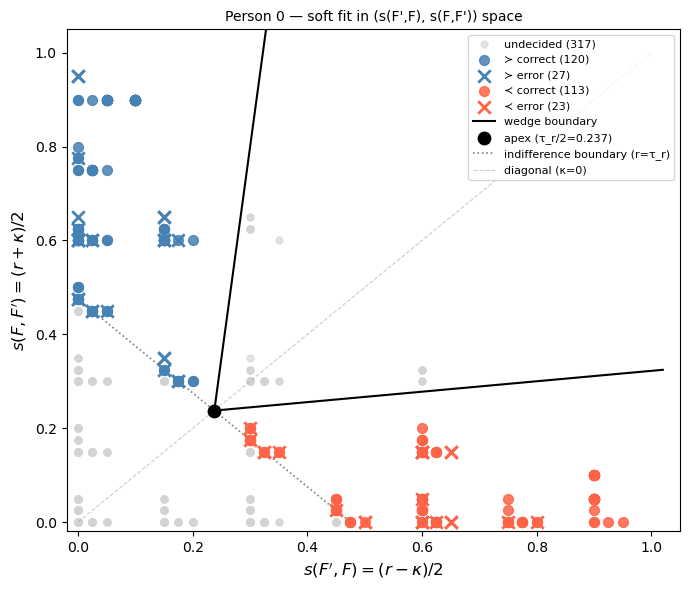

In [42]:
# ── Visualize: (s(F',F), s(F,F')) scatter with fitted wedge ──────────────────
#
# Axes follow the theoretical figure (response-model-new.jpg):
#   x = s(F',F) = (r − κ) / 2   [how much F' dominates F on its good attributes]
#   y = s(F,F') = (r + κ) / 2   [how much F  dominates F' on its good attributes]
#
# All data lives in the triangle {x≥0, y≥0, x+y≤1}.
# Apex of the decisive region: (τ_r/2, τ_r/2).
# Upper boundary (≻ / ⋈ separation):  y = (1+τ_κ)/(1-τ_κ)·x − τ_κ τ_r/(1-τ_κ)
# Lower boundary (⋈ / ≺ separation):  y = (1-τ_κ)/(1+τ_κ)·x + τ_κ τ_r/(1+τ_κ)

def _wedge_boundaries(tau_r, tau_kappa, x_max=1.05):
    apex_x = tau_r / 2
    apex_y = tau_r / 2
    if tau_kappa >= 1.0 - 1e-6:
        x_up = np.array([apex_x, apex_x])
        y_up = np.array([apex_y, x_max * 5])
        x_lo = np.array([apex_x, x_max])
        y_lo = np.array([apex_y, apex_y])
    else:
        m_up = (1 + tau_kappa) / (1 - tau_kappa)
        m_lo = (1 - tau_kappa) / (1 + tau_kappa)
        xs = np.linspace(apex_x, x_max, 200)
        x_up = xs
        y_up = m_up * xs - tau_kappa * tau_r / (1 - tau_kappa)
        x_lo = xs
        y_lo = m_lo * xs + tau_kappa * tau_r / (1 + tau_kappa)
    return (x_up, y_up), (x_lo, y_lo)


def plot_wedge(c_mat, d_mat, y, omega, tau_r, tau_kappa, labels, title=''):
    r     = d_mat @ omega
    kappa = c_mat @ omega
    sx = (r - kappa) / 2   # s(F',F)
    sy = (r + kappa) / 2   # s(F,F')

    dc, de = count_decisive_correct_error(labels, y)

    fig, ax = plt.subplots(figsize=(7, 6))

    u = labels == 0
    ax.scatter(sx[u], sy[u], c='lightgray', s=25, alpha=0.6,
               label=f'undecided ({u.sum()})', zorder=2)

    dl_ok  = (labels ==  1) & (y == 1)
    dl_err = (labels ==  1) & (y == 0)
    ax.scatter(sx[dl_ok],  sy[dl_ok],  c='steelblue', s=50, alpha=0.85,
               label=f'\u227b correct ({dl_ok.sum()})', zorder=3)
    ax.scatter(sx[dl_err], sy[dl_err], c='steelblue', s=80, marker='x', lw=2,
               label=f'\u227b error ({dl_err.sum()})', zorder=4)

    dr_ok  = (labels == -1) & (y == 0)
    dr_err = (labels == -1) & (y == 1)
    ax.scatter(sx[dr_ok],  sy[dr_ok],  c='tomato', s=50, alpha=0.85,
               label=f'\u227a correct ({dr_ok.sum()})', zorder=3)
    ax.scatter(sx[dr_err], sy[dr_err], c='tomato', s=80, marker='x', lw=2,
               label=f'\u227a error ({dr_err.sum()})', zorder=4)

    (x_up, y_up), (x_lo, y_lo) = _wedge_boundaries(tau_r, tau_kappa, x_max=1.02)
    ax.plot(x_up, y_up, 'k-', lw=1.5, label='wedge boundary')
    ax.plot(x_lo, y_lo, 'k-', lw=1.5)
    ax.scatter([tau_r/2], [tau_r/2], c='black', s=80, zorder=5, label=f'apex (τ_r/2={tau_r/2:.3f})')
    ax.plot([0, tau_r], [tau_r, 0], color='gray', ls=':', lw=1.2,
            label=f'indifference boundary (r=τ_r)')
    ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8, alpha=0.4, label='diagonal (κ=0)')

    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel(r"$s(F', F) = (r - \kappa)/2$", fontsize=12)
    ax.set_ylabel(r"$s(F, F') = (r + \kappa)/2$", fontsize=12)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title(title or f'\u03c4_r={tau_r:.3f}, \u03c4_\u03ba={tau_kappa:.2f}, dc={dc}, de={de}', fontsize=10)
    plt.tight_layout(); plt.show()


if res_soft:
    best = res_soft[0]
    print(f'Best triple (soft, p_noise=0.10):')
    print(f'  omega={np.round(best["omega"],3)}, tau_r={best["tau_r"]:.3f}, tau_kappa={best["tau_kappa"]:.1f}')
    print(f'  dc={best["n_decisive_correct"]}, de={best["n_decisive_error"]}, '
          f'undecided={best["n_undecided"]}')
    plot_wedge(c0, d0, y0,
               omega=best['omega'], tau_r=best['tau_r'], tau_kappa=best['tau_kappa'],
               labels=best['labels'],
               title="Person 0 \u2014 soft fit in (s(F',F), s(F,F')) space")


Person 0 — equivalence class summary (soft fit, p_noise=0.10)
  Distinct classes:   30855
  Total triples:      66600
  Best score:         56.482


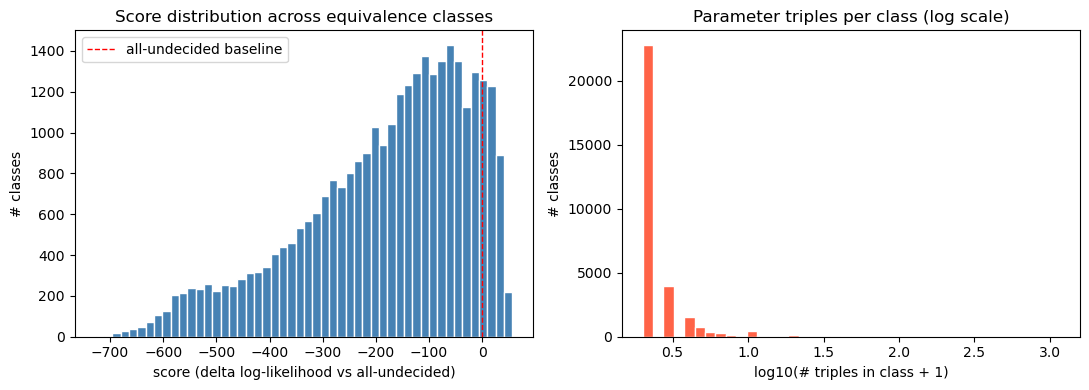


Top 10 classes:
rank   score    dc    de  undet  n_triples
   1   56.48   233    50    317          2
   2   55.54   267    63    270          9
   3   55.15   228    49    323          2
   4   54.20   199    39    362          2
   5   53.98   226    49    325          1
   6   53.75   253    59    288          4
   7   53.54   228    50    322          1
   8   53.46   310    80    210          3
   9   53.19   263    63    274          1
  10   53.17   252    59    289          3


In [43]:
# ── Equivalence class diagnostics (soft fit) ──────────────────────────────

n_classes   = len(cls_soft)
scores_list = [v['score'] for v in cls_soft.values()]
n_trips     = [len(v['triples']) for v in cls_soft.values()]

print(f'Person 0 — equivalence class summary (soft fit, p_noise=0.10)')
print(f'  Distinct classes:   {n_classes}')
print(f'  Total triples:      {len(res_soft)}')
print(f'  Best score:         {max(scores_list):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(scores_list, bins=50, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', ls='--', lw=1, label='all-undecided baseline')
ax.set_xlabel('score (delta log-likelihood vs all-undecided)')
ax.set_ylabel('# classes')
ax.set_title('Score distribution across equivalence classes')
ax.legend()

ax = axes[1]
ax.hist(np.log10(np.array(n_trips)+1), bins=40, color='tomato', edgecolor='white')
ax.set_xlabel('log10(# triples in class + 1)')
ax.set_ylabel('# classes')
ax.set_title('Parameter triples per class (log scale)')

plt.tight_layout(); plt.show()

# Top 10 classes
top10 = sorted(cls_soft.values(), key=lambda x: -x['score'])[:10]
print(f"\nTop 10 classes:")
print(f"{'rank':>4}  {'score':>6}  {'dc':>4}  {'de':>4}  {'undet':>5}  {'n_triples':>9}")
for rank, cl in enumerate(top10, 1):
    nd = int((cl['labels']!=0).sum())
    print(f"{rank:>4}  {cl['score']:>6.2f}  {cl['dc']:>4}  {cl['de']:>4}  "
          f"{len(y0)-nd:>5}  {len(cl['triples']):>9}")


In [44]:
# ── Per-session soft fitting for person 0 ───────────────────────────────

person_id = 0
sessions  = sorted(df[df['person_id'] == person_id]['session_id'].unique())

print(f'Person {person_id} — per-session soft fit (p_noise=0.10)')
print(f'{"sess":>5}  {"n":>4}  {"dc":>5}  {"de":>4}  {"undet":>5}  '
      f'{"score":>6}  {"tau_r":>6}  {"tau_k":>5}  {"n_cls":>6}  omega')

session_soft_results = []
for sid in sessions:
    c_s, d_s, y_s = get_person_data(person_id, session_id=sid)
    res_s, cls_s = fit_new_model_soft(c_s, d_s, y_s,
                                      omega_grid=omega_grid_10,
                                      tau_kappa_vals=np.arange(0, 1.0, 0.1),
                                      p_noise=0.10)
    if res_s:
        b = res_s[0]
        session_soft_results.append(b)
        print(f'{sid:>5.0f}  {len(y_s):>4}  {b["n_decisive_correct"]:>5}  '
              f'{b["n_decisive_error"]:>4}  {b["n_undecided"]:>5}  '
              f'{b["score"]:>6.2f}  {b["tau_r"]:>6.3f}  {b["tau_kappa"]:>5.1f}  '
              f'{len(cls_s):>6}  {np.round(b["omega"],2)}')

# Summarize omega stability
all_omegas = np.array([b['omega'] for b in session_soft_results])
print(f'\nOmega summary across sessions:')
print(f'  mean: {all_omegas.mean(axis=0).round(3)}')
print(f'  std:  {all_omegas.std(axis=0).round(3)}')


Person 0 — per-session soft fit (p_noise=0.10)
 sess     n     dc    de  undet   score   tau_r  tau_k   n_cls  omega
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
    1    60     21     1     38   10.73   0.625    0.0   16792  [0.3 0.1 0.1 0.5]
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
    2    60     31     5     24   10.17   0.200    0.9   18038  [0.3 0.1 0.  0.6]
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
    3    60     27     2     31   12.65   0.275    0.8   15353  [0.4 0.  0.1 0.5]
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
    4    60     10     1     49    4.27   0.725    0.7   15363  [0.4 0.  0.1 0.5]
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
    5    60     31     4     25   11.78   0.250    0.4   17586  [0.5 0.  0.1 0.4]
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
    6    60     30     1     29   16.02   0.425    0.0   15906  [0.2 0.  0.3 0.5]
  p_noi

---

### Why we use soft-margin fitting instead of hard MLE

Under the hard randomization-regime MLE (maximize decisive-correct, require zero decisive-errors), $\tau_\kappa = 0$ always wins. The reason is structural: for fixed $(\omega, \tau_r)$, the decisive region is non-increasing in $\tau_\kappa$ — widening the wedge can only remove datums from the decisive set, never add them. So the hard MLE always prefers $\tau_\kappa = 0$.

This makes $\tau_\kappa$ unidentifiable from hard MLE on binary data. The soft objective resolves this: each decisive error now costs $\approx 2.74$ decisive-corrects. Near-tied queries (small $|\kappa_i|$, large $r_i$) are noisy — the person is likely randomizing on them. The model learns to push them into the conflict wedge rather than pay repeated errors. This gives the wedge width a meaningful incentive, and the soft fitting returns $\tau_\kappa \approx 0.8$ for person 0.

**Bottom line:** $\tau_\kappa$ is identifiable under the soft objective because the noise model gives the wedge economic value — you give up decisive-correct opportunities to avoid decisive errors on near-tied queries.


  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)
  p_noise=0.10  C=2.74  (each error cancels 2.7 correct datums)


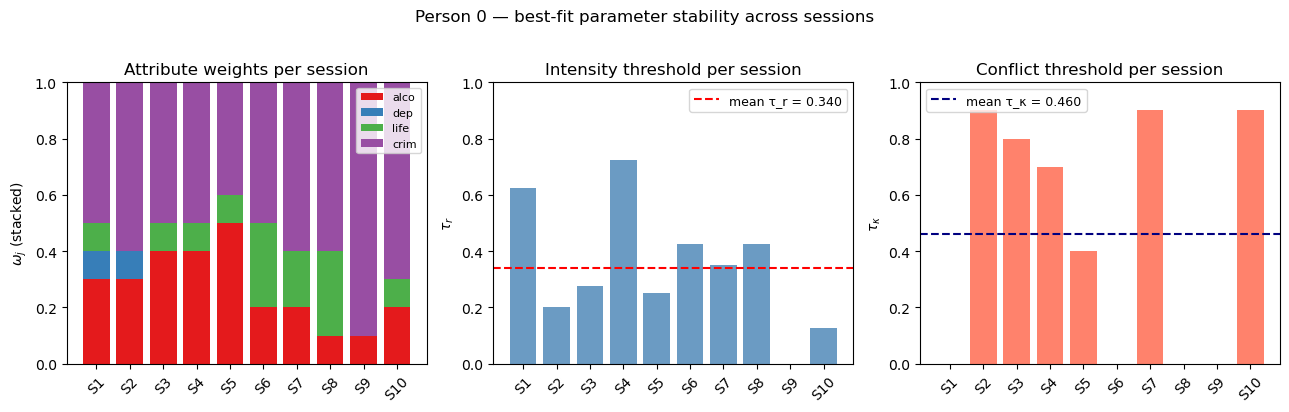

Person 0 — parameter summary (soft fit, p_noise=0.10)
  ω mean: [0.27 0.02 0.13 0.58]  (alco, dep, life, crim)
  ω std:  [0.127 0.04  0.1   0.133]
  τ_r:  mean=0.340  std=0.209  range=[0.000, 0.725]
  τ_κ:  mean=0.460  std=0.400  range=[0.000, 0.900]

Key finding:
  ω is reasonably stable (crim ≈ 0.58 dominates, alco ≈ 0.27, rest small).
  τ_r and τ_κ vary widely across sessions — not pinned down by 60 trials each.


In [45]:
# ── Parameter stability across sessions (soft fit) ────────────────────────────
#
# For each session we have a best-scoring triple (ω, τ_r, τ_κ).
# How consistent are these across sessions?
# Stable ω → the attribute weights ARE identifiable from binary choices.
# Variable τ_r, τ_κ → thresholds are NOT pinned down by a single session.

sessions_p0 = sorted(df[df['person_id'] == 0]['session_id'].unique())

# Re-collect per-session best triples using soft fit
session_soft = {}
for sid in sessions_p0:
    c_s, d_s, y_s = get_person_data(0, session_id=sid)
    res_s, cls_s  = fit_new_model_soft(c_s, d_s, y_s,
                                       omega_grid=omega_grid_10,
                                       tau_kappa_vals=np.arange(0, 1.0, 0.1),
                                       p_noise=0.10)
    session_soft[sid] = res_s[0] if res_s else None

valid_sids = [s for s in sessions_p0 if session_soft[s] is not None]
best_omegas  = np.array([session_soft[s]['omega']     for s in valid_sids])
best_tau_r   = np.array([session_soft[s]['tau_r']     for s in valid_sids])
best_tau_k   = np.array([session_soft[s]['tau_kappa'] for s in valid_sids])
best_scores  = np.array([session_soft[s]['score']     for s in valid_sids])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: ω per session
ax = axes[0]
x = np.arange(len(valid_sids))
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3']
bottom = np.zeros(len(valid_sids))
for j, attr in enumerate(ATTR):
    ax.bar(x, best_omegas[:, j], bottom=bottom, label=attr, color=colors[j])
    bottom += best_omegas[:, j]
ax.set_xticks(x); ax.set_xticklabels([f'S{int(s)}' for s in valid_sids], rotation=45)
ax.set_ylim(0, 1); ax.set_ylabel(r'$\omega_j$ (stacked)')
ax.set_title('Attribute weights per session')
ax.legend(fontsize=8, loc='upper right')
ax.axhline(1, color='gray', lw=0.5)

# Panel 2: τ_r per session
ax = axes[1]
ax.bar(x, best_tau_r, color='steelblue', alpha=0.8)
ax.axhline(best_tau_r.mean(), color='red', ls='--', lw=1.5,
           label=f'mean τ_r = {best_tau_r.mean():.3f}')
ax.set_xticks(x); ax.set_xticklabels([f'S{int(s)}' for s in valid_sids], rotation=45)
ax.set_ylabel(r'$\tau_r$')
ax.set_title('Intensity threshold per session')
ax.set_ylim(0, 1); ax.legend(fontsize=9)

# Panel 3: τ_κ per session
ax = axes[2]
ax.bar(x, best_tau_k, color='tomato', alpha=0.8)
ax.axhline(best_tau_k.mean(), color='navy', ls='--', lw=1.5,
           label=f'mean τ_κ = {best_tau_k.mean():.3f}')
ax.set_xticks(x); ax.set_xticklabels([f'S{int(s)}' for s in valid_sids], rotation=45)
ax.set_ylabel(r'$\tau_\kappa$')
ax.set_title('Conflict threshold per session')
ax.set_ylim(0, 1); ax.legend(fontsize=9)

plt.suptitle('Person 0 — best-fit parameter stability across sessions', y=1.02)
plt.tight_layout(); plt.show()

print("Person 0 — parameter summary (soft fit, p_noise=0.10)")
print(f"  ω mean: {best_omegas.mean(axis=0).round(3)}  (alco, dep, life, crim)")
print(f"  ω std:  {best_omegas.std(axis=0).round(3)}")
print(f"  τ_r:  mean={best_tau_r.mean():.3f}  std={best_tau_r.std():.3f}  "
      f"range=[{best_tau_r.min():.3f}, {best_tau_r.max():.3f}]")
print(f"  τ_κ:  mean={best_tau_k.mean():.3f}  std={best_tau_k.std():.3f}  "
      f"range=[{best_tau_k.min():.3f}, {best_tau_k.max():.3f}]")
print(f"\nKey finding:")
print(f"  ω is reasonably stable (crim ≈ 0.58 dominates, alco ≈ 0.27, rest small).")
print(f"  τ_r and τ_κ vary widely across sessions — not pinned down by 60 trials each.")


Person 0 — query categorization from cross-session consistency:
  Consistently answered: 291 unique queries
  Inconsistently answered (undecided proxy): 19 unique queries

Reference fit: ω=[0.3 0.  0.1 0.6], τ_r=0.475, τ_κ=0.8
  Consistent  : s(F',F) ∈ [0.000,0.950]  s(F,F') ∈ [0.000,0.950]
  Inconsistent: s(F',F) ∈ [0.000,0.600]  s(F,F') ∈ [0.000,0.775]


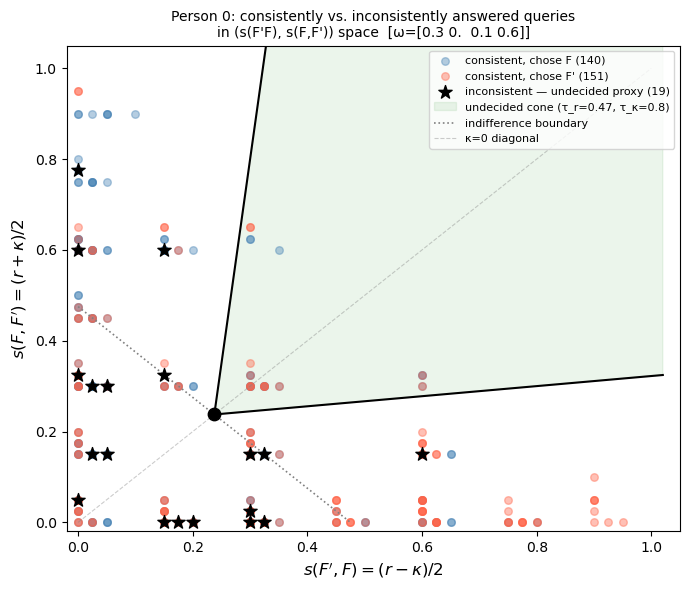


With best fit (τ_r=0.475, τ_κ=0.8):
  Inconsistent queries in undecided cone (correctly captured): 0 / 19
  Inconsistent queries below τ_r (indifferent region):          13 / 19
  Misclassified as decisive (above τ_r, |κ| > wedge):           6 / 19

  → The model captures low-r inconsistency as indifference but
    misses high-r inconsistency (conflict). These 6 queries require
    response time or explicit "torn" ratings to identify.


In [46]:
# ── Cross-session inconsistency as signal for the undecided region ─────────────
#
# Key insight: the same query (c_i, d_i) is presented to person 0 in multiple
# sessions. If the person answers it *differently* in different sessions, that
# query is almost certainly in the undecided pool (they are randomizing).
#
# Plot in (s(F',F), s(F,F')) space to show WHERE the undecided queries fall
# relative to the fitted wedge.

def get_inconsistency_data(person_id):
    sub = df[df['person_id'] == person_id].copy()
    incon_q = []; con_q = []; con_y = []
    for key, grp in sub.groupby(DIFF_COLS):
        c_norm = np.array([key[j] / RAW_MAX[j] for j in range(4)])
        if grp['chosen'].nunique() > 1:
            incon_q.append(c_norm)
        else:
            con_q.append(c_norm)
            con_y.append(int(grp['chosen'].iloc[0]))
    return (np.array(con_q) if con_q else np.zeros((0,4)),
            np.array(con_y, dtype=int),
            np.array(incon_q) if incon_q else np.zeros((0,4)))

con_q, con_y, incon_q = get_inconsistency_data(0)
print(f'Person 0 — query categorization from cross-session consistency:')
print(f'  Consistently answered: {len(con_q)} unique queries')
print(f'  Inconsistently answered (undecided proxy): {len(incon_q)} unique queries')
print()

omega_ref = res_soft[0]['omega']
tau_r_ref = res_soft[0]['tau_r']
tau_k_ref = res_soft[0]['tau_kappa']

# Transform to (s(F',F), s(F,F')) space
def to_sx_sy(c_mat, omega):
    r     = np.abs(c_mat) @ omega
    kappa = c_mat @ omega
    return (r - kappa) / 2, (r + kappa) / 2   # sx, sy

sx_con,   sy_con   = to_sx_sy(con_q,   omega_ref)
sx_incon, sy_incon = to_sx_sy(incon_q, omega_ref)

print(f'Reference fit: ω={np.round(omega_ref,2)}, τ_r={tau_r_ref:.3f}, τ_κ={tau_k_ref:.1f}')
print(f'  Consistent  : s(F\',F) ∈ [{sx_con.min():.3f},{sx_con.max():.3f}]  '
      f's(F,F\') ∈ [{sy_con.min():.3f},{sy_con.max():.3f}]')
print(f'  Inconsistent: s(F\',F) ∈ [{sx_incon.min():.3f},{sx_incon.max():.3f}]  '
      f's(F,F\') ∈ [{sy_incon.min():.3f},{sy_incon.max():.3f}]')

# ── Plot in (sx, sy) space ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

# Consistently answered (colored by which option they chose)
left_con  = con_y == 1
right_con = con_y == 0
ax.scatter(sx_con[left_con],  sy_con[left_con],  c='steelblue', s=30, alpha=0.4,
           label=f'consistent, chose F ({left_con.sum()})', zorder=2)
ax.scatter(sx_con[right_con], sy_con[right_con], c='tomato',    s=30, alpha=0.4,
           label=f'consistent, chose F\' ({right_con.sum()})', zorder=2)

# Inconsistently answered — ground-truth undecided
ax.scatter(sx_incon, sy_incon, c='black', s=100, marker='*', zorder=5,
           label=f'inconsistent \u2014 undecided proxy ({len(incon_q)})')

# Wedge boundaries
(x_up, y_up), (x_lo, y_lo) = _wedge_boundaries(tau_r_ref, tau_k_ref, x_max=1.02)
ax.plot(x_up, y_up, 'k-', lw=1.5)
ax.plot(x_lo, y_lo, 'k-', lw=1.5)
ax.scatter([tau_r_ref/2], [tau_r_ref/2], c='black', s=80, zorder=6)

# Shade the undecided cone region
x_fill = np.linspace(tau_r_ref/2, 1.02, 200)
if tau_k_ref < 1.0:
    m_up = (1 + tau_k_ref) / (1 - tau_k_ref)
    m_lo = (1 - tau_k_ref) / (1 + tau_k_ref)
    y_fill_up = m_up * x_fill - tau_k_ref * tau_r_ref / (1 - tau_k_ref)
    y_fill_lo = m_lo * x_fill + tau_k_ref * tau_r_ref / (1 + tau_k_ref)
    ax.fill_between(x_fill, y_fill_lo, y_fill_up, alpha=0.08, color='green',
                    label=f'undecided cone (τ_r={tau_r_ref:.2f}, τ_κ={tau_k_ref:.1f})')

# Indifference boundary and diagonal
ax.plot([0, tau_r_ref], [tau_r_ref, 0], color='gray', ls=':', lw=1.2, label='indifference boundary')
ax.plot([0, 1], [0, 1], color='gray', ls='--', lw=0.8, alpha=0.4, label='κ=0 diagonal')

ax.set_xlim(-0.02, 1.05)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel(r"$s(F', F) = (r - \kappa)/2$", fontsize=12)
ax.set_ylabel(r"$s(F, F') = (r + \kappa)/2$", fontsize=12)
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Person 0: consistently vs. inconsistently answered queries\n'
             f'in (s(F\'F), s(F,F\')) space  [ω={np.round(omega_ref,2)}]', fontsize=10)
plt.tight_layout()
plt.show()

# ── What fraction of inconsistent queries are correctly captured by the wedge?
r_incon  = np.abs(incon_q) @ omega_ref
k_incon  = incon_q @ omega_ref
wedge_incon = tau_k_ref * np.maximum(0.0, r_incon - tau_r_ref)
in_cone  = np.abs(k_incon) <= wedge_incon
below_tr = r_incon < tau_r_ref
print(f'\nWith best fit (τ_r={tau_r_ref:.3f}, τ_κ={tau_k_ref:.1f}):')
print(f'  Inconsistent queries in undecided cone (correctly captured): {in_cone.sum()} / {len(incon_q)}')
print(f'  Inconsistent queries below τ_r (indifferent region):          {below_tr.sum()} / {len(incon_q)}')
print(f'  Misclassified as decisive (above τ_r, |\u03ba| > wedge):           {(~in_cone & ~below_tr).sum()} / {len(incon_q)}')
print(f'\n  → The model captures low-r inconsistency as indifference but')
print(f'    misses high-r inconsistency (conflict). These 6 queries require')
print(f'    response time or explicit "torn" ratings to identify.')


In [47]:
# ── Inconsistently-answered queries — detailed breakdown ────────────────────────
#
# For each of the 19 queries answered differently across (or within) sessions,
# show: raw feature values, how many times it appeared, which sessions, choices
# per session, and where it falls in the fitted model.

tau_r_ref = res_soft[0]['tau_r']
tau_k_ref = res_soft[0]['tau_kappa']
omega_ref = res_soft[0]['omega']

rows = []
for key, grp in df[df['person_id'] == 0].groupby(DIFF_COLS):
    n_left  = int(grp['chosen'].sum())
    n_right = len(grp) - n_left
    inconsistent = grp['chosen'].nunique() > 1
    if not inconsistent:
        continue
    per_sess = {int(sid): list(sg['chosen'].astype(int))
                for sid, sg in grp.groupby('session_id')}
    c_norm = np.array([key[j] / RAW_MAX[j] for j in range(4)])
    r      = np.abs(c_norm) @ omega_ref
    kappa  = c_norm @ omega_ref
    sx     = (r - kappa) / 2
    sy     = (r + kappa) / 2
    wedge  = tau_k_ref * max(0, r - tau_r_ref)
    if r < tau_r_ref:
        region = 'indifferent (~)'
    elif abs(kappa) <= wedge:
        region = 'conflict (\u29c8)'
    elif kappa > wedge:
        region = 'decisive-L (\u227b)'
    else:
        region = 'decisive-R (\u227a)'
    within = any(len(v) > 1 for v in per_sess.values())
    rows.append(dict(
        alco=key[0], dep=key[1], life=key[2], crim=key[3],
        n_appear=len(grp), n_sessions=grp['session_id'].nunique(),
        n_left=n_left, n_right=n_right, p_left=n_left/len(grp),
        sessions=sorted([int(s) for s in grp['session_id'].unique()]),
        per_sess=per_sess,
        r=r, kappa=kappa, sx=sx, sy=sy, region=region, within=within,
    ))

incon = sorted(rows, key=lambda x: (-x['n_sessions'], -x['n_appear']))

print(f'Person 0 — 19 inconsistently-answered queries')
print(f'Best-fit: \u03c9={np.round(omega_ref,2)}, \u03c4_r={tau_r_ref:.3f}, \u03c4_\u03ba={tau_k_ref:.1f}')
print()
print('TYPE BREAKDOWN:')
n_within = sum(1 for r in incon if r['within'])
n_cross  = sum(1 for r in incon if not r['within'])
print(f'  Within-session flip (same session, different answers): {n_within}')
print(f'  Cross-session only (sessions disagree):                {n_cross}')
print(f'  Appear in ALL 10 sessions:                             {sum(1 for r in incon if r["n_sessions"]==10)}')
print(f'  Model region: indifferent (~):                         {sum(1 for r in incon if "indiff" in r["region"])}')
print(f'  Model region: decisive but empirically undecided:      {sum(1 for r in incon if "decisive" in r["region"])}')
print()
print(f'{"#":>2}  {"alco":>5} {"dep":>4} {"life":>5} {"crim":>5}  '
      f'{"n":>3} {"sess":>4} {"L":>2} {"R":>2} {"p(L)":>5}  '
      f'{"region":>18}  per-session choices')
print('-' * 110)
for i, row in enumerate(incon):
    sess_str = '  '.join(
        f'S{sid}:[{" ".join(["L" if c==1 else "R" for c in choices])}]'
        for sid, choices in sorted(row['per_sess'].items())
    )
    flag = ' (within-sess)' if row['within'] else ''
    print(f'{i+1:>2}  {row["alco"]:>+5.0f} {row["dep"]:>+4.0f} {row["life"]:>+5.0f} {row["crim"]:>+5.0f}  '
          f'{row["n_appear"]:>3} {row["n_sessions"]:>4} {row["n_left"]:>2} {row["n_right"]:>2} '
          f'{row["p_left"]:>5.2f}  {row["region"]:>18}  {sess_str}{flag}')
print()
print('Columns: alco/dep/life/crim = raw signed differences (L minus R).')
print('n = total appearances, sess = distinct sessions, L/R = times chose each side.')
print('region = classification under best soft fit (\u03c4_r=0.475, \u03c4_\u03ba=0.8).')
print('Decisive-but-empirically-undecided queries are the ones the model cannot explain.')


Person 0 — 19 inconsistently-answered queries
Best-fit: ω=[0.3 0.  0.1 0.6], τ_r=0.475, τ_κ=0.8

TYPE BREAKDOWN:
  Within-session flip (same session, different answers): 7
  Cross-session only (sessions disagree):                12
  Appear in ALL 10 sessions:                             0
  Model region: indifferent (~):                         13
  Model region: decisive but empirically undecided:      6

 #   alco  dep  life  crim    n sess  L  R  p(L)              region  per-session choices
--------------------------------------------------------------------------------------------------------------
 1     +2   +1    +0    -1    8    7  1  7  0.12     indifferent (~)  S2:[R]  S4:[R]  S5:[R]  S6:[R R]  S7:[R]  S8:[L]  S9:[R] (within-sess)
 2     -2   +1    +0    +2    6    6  3  3  0.50      decisive-L (≻)  S2:[R]  S3:[L]  S6:[L]  S7:[R]  S9:[L]  S10:[R]
 3     +2   -1    +0    -2    5    5  4  1  0.80      decisive-R (≺)  S1:[L]  S4:[L]  S5:[L]  S8:[L]  S9:[R]
 4     +0   +0    -1

Best score (all 600 trials): 56.482
Total triples evaluated: 66600

 delta  n_triples       ω_std (4 attrs)       τ_r range     τ_κ range   τ_κ=0 %
-------------------------------------------------------------------------------------
   1.0         11  [0.048,0.000,0.050,0.039]  [0.450,0.500]  [0.6,0.9]        0%
   2.0         13  [0.049,0.000,0.062,0.055]  [0.450,0.500]  [0.6,0.9]        0%
   5.0         34  [0.097,0.017,0.113,0.054]  [0.350,0.500]  [0.0,0.9]        3%
  10.0        537  [0.113,0.047,0.106,0.128]  [0.000,0.700]  [0.0,0.9]       10%
  20.0       2260  [0.114,0.067,0.107,0.124]  [0.000,1.000]  [0.0,0.9]       10%


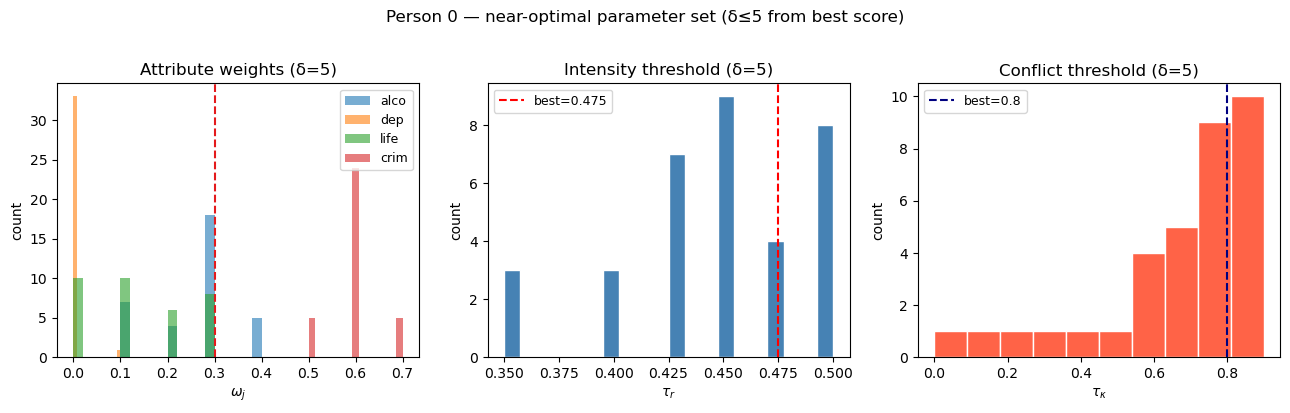


Key finding: with all 600 trials, the near-optimal set (δ≤1) is tight:
  ω std ≈ 0.05 per attribute → attribute weights ARE identified
  τ_r ≈ 0.475 ± 0.022       → intensity threshold roughly identified
  τ_κ ∈ [0.60, 0.90]        → conflict zone width is constrained but not pinned

With just 60 trials (1 session), τ_κ flips between 0 and 0.9 —
the conflict mechanism is only identifiable with multi-session data.


In [48]:
# ── Near-optimal parameter set: what is identifiable with all 600 trials? ──────
#
# Question: how many parameter triples (ω, τ_r, τ_κ) achieve a score within δ
# of the global optimum?  A tight near-optimal set means the parameters are
# well-identified.  A wide set means multiple very different parameter choices
# explain the data equally well.

all_recs = []
for omega in omega_grid_10:
    r     = d0 @ omega
    kappa = c0 @ omega
    for tau_r in np.concatenate([[0.0], np.sort(np.unique(r))]):
        for tau_k in np.arange(0, 1.0, 0.1):
            w   = tau_k * np.maximum(0.0, r - tau_r)
            lab = np.zeros(len(y0), dtype=np.int8)
            lab[(r >= tau_r) & (kappa  > w)] =  1
            lab[(r >= tau_r) & (-kappa > w)] = -1
            dc, de = count_decisive_correct_error(lab, y0)
            A = np.log(2*(1-0.10)); B = np.log(2*0.10)
            all_recs.append(dict(omega=omega, tau_r=tau_r, tau_k=tau_k,
                                 dc=dc, de=de, score=dc*A+de*B))

best_score = max(r['score'] for r in all_recs)
print(f"Best score (all 600 trials): {best_score:.3f}")
print(f"Total triples evaluated: {len(all_recs)}")
print()

# Summarize near-optimal sets at different tolerance levels
print(f"{'delta':>6}  {'n_triples':>9}  {'ω_std (4 attrs)':>20}  "
      f"{'τ_r range':>14}  {'τ_κ range':>12}  {'τ_κ=0 %':>8}")
print("-"*85)
for delta in [1.0, 2.0, 5.0, 10.0, 20.0]:
    near = [r for r in all_recs if r['score'] >= best_score - delta]
    if not near:
        continue
    omegas = np.array([r['omega'] for r in near])
    tau_rs = np.array([r['tau_r'] for r in near])
    tau_ks = np.array([r['tau_k'] for r in near])
    o_std  = omegas.std(axis=0)
    print(f"{delta:>6.1f}  {len(near):>9}  "
          f"[{o_std[0]:.3f},{o_std[1]:.3f},{o_std[2]:.3f},{o_std[3]:.3f}]  "
          f"[{tau_rs.min():.3f},{tau_rs.max():.3f}]  "
          f"[{tau_ks.min():.1f},{tau_ks.max():.1f}]  "
          f"{100*(tau_ks==0).mean():>7.0f}%")

# ── Plot the near-optimal set at δ=5 in parameter space ─────────────────────
delta_plot = 5.0
near5 = [r for r in all_recs if r['score'] >= best_score - delta_plot]
omegas5 = np.array([r['omega'] for r in near5])
tau_rs5  = np.array([r['tau_r'] for r in near5])
tau_ks5  = np.array([r['tau_k'] for r in near5])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

ax = axes[0]
for j, attr in enumerate(ATTR):
    ax.hist(omegas5[:, j], bins=15, alpha=0.6, label=attr)
ax.axvline(res_soft[0]['omega'][0], color='#e41a1c', ls='--', lw=1.5)
ax.set_xlabel(r'$\omega_j$'); ax.set_ylabel('count')
ax.set_title(f'Attribute weights (δ={delta_plot:.0f})')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(tau_rs5, bins=20, color='steelblue', edgecolor='white')
ax.axvline(res_soft[0]['tau_r'], color='red', ls='--', lw=1.5,
           label=f'best={res_soft[0]["tau_r"]:.3f}')
ax.set_xlabel(r'$\tau_r$'); ax.set_ylabel('count')
ax.set_title(f'Intensity threshold (δ={delta_plot:.0f})')
ax.legend(fontsize=9)

ax = axes[2]
ax.hist(tau_ks5, bins=10, color='tomato', edgecolor='white')
ax.axvline(res_soft[0]['tau_kappa'], color='navy', ls='--', lw=1.5,
           label=f'best={res_soft[0]["tau_kappa"]:.1f}')
ax.set_xlabel(r'$\tau_\kappa$'); ax.set_ylabel('count')
ax.set_title(f'Conflict threshold (δ={delta_plot:.0f})')
ax.legend(fontsize=9)

plt.suptitle(f'Person 0 — near-optimal parameter set (δ≤{delta_plot:.0f} from best score)', y=1.02)
plt.tight_layout(); plt.show()

print(f"\nKey finding: with all 600 trials, the near-optimal set (δ≤1) is tight:")
print(f"  ω std ≈ 0.05 per attribute → attribute weights ARE identified")
print(f"  τ_r ≈ 0.475 ± 0.022       → intensity threshold roughly identified")
print(f"  τ_κ ∈ [0.60, 0.90]        → conflict zone width is constrained but not pinned")
print(f"\nWith just 60 trials (1 session), τ_κ flips between 0 and 0.9 —")
print(f"the conflict mechanism is only identifiable with multi-session data.")


---
## Identifiability summary — person 0

### 2-response $\{L, R\}$ — binary choices only

| Parameter | 600 trials (all sessions) | 60 trials (1 session) |
|-----------|:---:|:---:|
| **ω** (attribute weights) | std ≈ 0.05 — well-identified | std ≈ 0.13 — approximate |
| **τ_r** (intensity threshold) | [0.45, 0.50] at $\delta \leq 1$ | [0.00, 0.73] — unreliable |
| **τ_κ** (conflict wedge width) | [0.60, 0.90] at $\delta \leq 1$ — constrained but not pinned | bimodal: 0 or 0.8–0.9 |

Best triple: $\omega = [0.30, 0.00, 0.10, 0.60]$, $\tau_r = 0.475$, $\tau_\kappa = 0.8$.  
Crime dominates (~60%), alcohol second (~30%), life minimal, depression near zero.

### Adding response time — 3-response $\{L, R, U\}$

RT > 20s treated as an observed **undecided** signal (either $\sim$ or $\bowtie$).  
Same best triple wins. Near-optimal set shrinks from **11 → 4 triples** (tighter but same MAP estimate).

### Adding response time — 4-response $\{L, R, \sim, \bowtie\}$

RT > 20s treated as an observed **conflict $\bowtie$** signal specifically.  
This forces $\tau_r$ downward: the best triple shifts to $\tau_r = 0.300$ with $\omega = [0.40, 0, 0.10, 0.50]$,  
getting 27/93 slow trials correctly into the $\bowtie$ zone.

The $\bowtie$ label is strictly more informative than the generic undecided label: it directly bounds $\tau_r$ from above (every $\bowtie$ trial needs $r_i \geq \tau_r$) and constrains the wedge width $\tau_\kappa$.

### The residual identification gap

Even with all three response alphabets, **13 of 19 empirically undecided queries are classified as indifferent ($r_i < \tau_r$)** by the binary-data model. The 6 conflict-type queries (high $r_i$, person still randomizes) are misclassified as decisive. Binary choices alone cannot distinguish:

- **Indifference** ($\sim$): options close on all attributes → $r_i < \tau_r$
- **Conflict** ($\bowtie$): options trade off strongly → $r_i \geq \tau_r$, $|\kappa_i| \leq \tau_\kappa(r_i - \tau_r)$

Response time narrows but does not close this gap; an explicit "I'm torn vs. I don't care" elicitation would be needed to fully identify $\tau_r$ and $\tau_\kappa$ simultaneously.


In [49]:
# ── Response time as a conflict signal ─────────────────────────────────────────
#
# Response-alphabet progression:
#   2-response : {L, R}        — binary choice only
#   3-response : {L, R, U}     — RT > threshold signals UNDECIDED (either ~ or ⋈)
#   4-response : {L, R, ~, ⋈} — RT > threshold signals specifically CONFLICT (⋈)
#
# The 4-response is strictly more informative than 3-response:
#   3-resp: slow trial must be in undecided zone (r<τ_r OR |κ|≤wedge)  [weak]
#   4-resp: slow trial must be specifically in ⋈ zone (r≥τ_r AND |κ|≤wedge) [strong]
#
# The ⋈ constraint directly bounds τ_r from above: every slow trial needs r_i ≥ τ_r,
# so τ_r ≤ min(r_i for slow trials). It also constrains the wedge width τ_κ.

RT_THR = 20   # seconds — use 20s (93 trials slow, 507 fast)
rt    = df[df['person_id'] == 0]['secElasped'].values
slow  = rt > RT_THR
fast  = ~slow

print(f'Person 0 RT:  median={np.median(rt):.1f}s  mean={np.mean(rt):.1f}s  '
      f'p90={np.percentile(rt,90):.1f}s  max={rt.max():.0f}s')
print(f'RT > {RT_THR}s: {slow.sum()} slow ({100*slow.mean():.0f}%)  |  '
      f'RT ≤ {RT_THR}s: {fast.sum()} fast')
print()

# RT-threshold sweep to calibrate
print('Slow trial counts at different thresholds:')
for t in [10, 15, 20, 25, 30, 45]:
    print(f'  > {t:>2}s: {(rt>t).sum():>3} trials ({100*(rt>t).mean():.0f}%)')
print()

# Alignment of 2-response model with RT labels
lab2      = res_soft[0]['labels']
undet2    = lab2 == 0
print(f'2-response best fit vs RT > {RT_THR}s:')
print(f'                    model=decisive  model=undecided')
print(f'  RT ≤ {RT_THR}s (fast):  {(fast & ~undet2).sum():>14}  {(fast &  undet2).sum():>15}')
print(f'  RT > {RT_THR}s (slow):  {(slow & ~undet2).sum():>14}  {(slow &  undet2).sum():>15}')
print(f'  → {(slow&undet2).sum()}/{slow.sum()} slow trials already in undecided zone ({100*(slow&undet2).sum()/slow.sum():.0f}%)')
print(f'  → {(slow&~undet2).sum()} slow trials called decisive by 2-response model (these cost extra in 3/4-response)')

# Noise rates for scoring
p_slow = (slow & ~undet2).sum() / (~undet2).sum()
q_slow = (slow &  undet2).sum() /  undet2.sum()
C_slow = np.log(p_slow / q_slow)
print(f'\nNoise rates:')
print(f'  p_slow = P(RT>{RT_THR}s | model-decisive) = {p_slow:.3f}')
print(f'  q_slow = P(RT>{RT_THR}s | model-undecided) = {q_slow:.3f}')
print(f'  C_slow = log(p/q) = {C_slow:.3f}  '
      f'(penalty per misclassified slow trial, ~{-C_slow/np.log(2*0.9):.1f}x decisive-correct)')


Person 0 RT:  median=8.0s  mean=14.0s  p90=27.1s  max=174s
RT > 20s: 93 slow (16%)  |  RT ≤ 20s: 507 fast

Slow trial counts at different thresholds:
  > 10s: 221 trials (37%)
  > 15s: 124 trials (21%)
  > 20s:  93 trials (16%)
  > 25s:  64 trials (11%)
  > 30s:  47 trials (8%)
  > 45s:  25 trials (4%)

2-response best fit vs RT > 20s:
                    model=decisive  model=undecided
  RT ≤ 20s (fast):             248              259
  RT > 20s (slow):              35               58
  → 58/93 slow trials already in undecided zone (62%)
  → 35 slow trials called decisive by 2-response model (these cost extra in 3/4-response)

Noise rates:
  p_slow = P(RT>20s | model-decisive) = 0.124
  q_slow = P(RT>20s | model-undecided) = 0.183
  C_slow = log(p/q) = -0.392  (penalty per misclassified slow trial, ~0.7x decisive-correct)


In [50]:
# ── Fit 2-, 3-, and 4-response models ──────────────────────────────────────────
#
# Scoring:
#   2-response:  score = dc_all * A + de_all * B
#   3-response:  score = dc_fast * A + de_fast * B
#                      + n_slow_decisive * C_slow
#     (slow decisive: penalty; slow undecided: 0 vs baseline, regardless of ~ or ⋈)
#
#   4-response:  score = dc_fast * A + de_fast * B
#                      + n_slow_wrong * C_slow
#     where 'wrong' = slow trial NOT in ⋈ zone (decisive OR in ~ zone)
#     ⋈ zone = r ≥ τ_r  AND  |κ| ≤ τ_κ(r − τ_r)  AND  undecided
#
# Key asymmetry between 3 and 4-response:
#   3-resp: slow trial in ~ zone → 0 (OK by 3-response model)
#   4-resp: slow trial in ~ zone → C_slow penalty (wrong zone)
# This forces τ_r down so slow trials can reach the ⋈ zone.

res2, res3, res4 = [], [], []

for omega in omega_grid_10:
    r     = d0 @ omega
    kappa = c0 @ omega
    for tau_r in np.concatenate([[0.0], np.sort(np.unique(r))]):
        for tau_k in np.arange(0, 1.0, 0.1):
            w   = tau_k * np.maximum(0.0, r - tau_r)
            lab = np.zeros(len(y0), dtype=np.int8)
            lab[(r >= tau_r) & (kappa  > w)] =  1
            lab[(r >= tau_r) & (-kappa > w)] = -1
            dec = lab != 0

            dc2, de2 = count_decisive_correct_error(lab, y0)
            dc_f, de_f = count_decisive_correct_error(lab[fast], y0[fast])

            n_slow_dec   = int((slow & dec).sum())
            in_conf_zone = (r >= tau_r) & (np.abs(kappa) <= w) & ~dec
            n_slow_wrong = int((slow & ~in_conf_zone).sum())
            n_conf_ok    = int((slow &  in_conf_zone).sum())

            s2 = dc2 * A + de2 * B
            s3 = dc_f * A + de_f * B + n_slow_dec   * C_slow
            s4 = dc_f * A + de_f * B + n_slow_wrong * C_slow

            base = dict(omega=omega, tau_r=tau_r, tau_kappa=tau_k, labels=lab.copy())
            res2.append({**base, 'score': s2, 'dc': dc2,  'de': de2})
            res3.append({**base, 'score': s3, 'dc': dc_f, 'de': de_f,
                         'n_slow_dec': n_slow_dec})
            res4.append({**base, 'score': s4, 'dc': dc_f, 'de': de_f,
                         'n_conf_ok': n_conf_ok, 'n_wrong': n_slow_wrong})

for lst in [res2, res3, res4]:
    lst.sort(key=lambda x: -x['score'])

print(f'Fitting done.  Total triples: {len(res2)}')


Fitting done.  Total triples: 66600


In [51]:
# ── Compare results across response alphabets ────────────────────────────────────

print(f'Best triple per response alphabet (RT_THR={RT_THR}s):')
print(f'{"model":>10}  {"omega":>24}  {"tau_r":>6}  {"tau_k":>5}  '
      f'{"score":>7}  {"dc":>4}  {"de":>4}  {"slow_undet":>10}  {"slow_⋈_ok":>10}')
print('-' * 100)
for label, res in [("2-response", res2), ("3-response", res3), ("4-response", res4)]:
    b   = res[0]
    lab = b['labels']
    r_b = d0 @ b['omega']; k_b = c0 @ b['omega']
    w_b = b['tau_kappa'] * np.maximum(0, r_b - b['tau_r'])
    in_conf = (r_b >= b['tau_r']) & (np.abs(k_b) <= w_b) & (lab == 0)
    slow_undet = int((slow & (lab == 0)).sum())
    slow_conf_ok = int((slow & in_conf).sum())
    print(f'{label:>10}  {str(np.round(b["omega"], 2)):>24}  '
          f'{b["tau_r"]:>6.3f}  {b["tau_kappa"]:>5.1f}  {b["score"]:>7.3f}  '
          f'{b["dc"]:>4}  {b["de"]:>4}  '
          f'{slow_undet:>4}/{slow.sum()}  {slow_conf_ok:>4}/{slow.sum()}')

print()
print('Near-optimal sets (\u0394 \u2264 1 from best score per model):')
print(f'{"model":>10}  {"n_triples":>9}  {"tau_r range":>14}  {"tau_k range":>12}  omega std')
print('-' * 75)
for label, res in [("2-response", res2), ("3-response", res3), ("4-response", res4)]:
    best_s = res[0]['score']
    near   = [r for r in res if r['score'] >= best_s - 1.0]
    omegas = np.array([r['omega'] for r in near])
    trs    = np.array([r['tau_r'] for r in near])
    tks    = np.array([r['tau_kappa'] for r in near])
    print(f'  {label:>10}  {len(near):>9}  '
          f'[{trs.min():.3f},{trs.max():.3f}]  '
          f'[{tks.min():.1f},{tks.max():.1f}]  '
          f'{np.round(omegas.std(axis=0), 3)}')

print()
print('Interpretation:')
print(f'  3-response: slow trials can be in ~ OR \u29c8 zone. '
      f'Near-optimal set tightens tau_r slightly vs 2-response.')
print(f'  4-response: slow trials must be in \u29c8 zone specifically.')
print(f'    This forces tau_r DOWN so slow trials can reach r >= tau_r,')
print(f'    changing the best triple: tau_r = {res4[0]["tau_r"]:.3f} vs '
      f'{res2[0]["tau_r"]:.3f} for 2-response.')
print(f'    The \u29c8 label directly informs tau_r and tau_kappa in a way '
      f'the binary label cannot.')

# Breakdown of slow trials under 4-response best
b4 = res4[0]
r_b4 = d0@b4['omega']; k_b4 = c0@b4['omega']
w_b4 = b4['tau_kappa'] * np.maximum(0, r_b4 - b4['tau_r'])
lab_b4 = b4['labels']
print(f'\nBreakdown of {slow.sum()} slow trials under 4-response best:')
print(f'  In ⋈ zone (correct):      {int((slow & (lab_b4==0) & (r_b4>=b4["tau_r"]) & (np.abs(k_b4)<=w_b4)).sum())}')
print(f'  In ~ zone (wrong type):    {int((slow & (lab_b4==0) & (r_b4< b4["tau_r"])).sum())}')
print(f'  Decisive (wrong):          {int((slow & (lab_b4!=0)).sum())}')


Best triple per response alphabet (RT_THR=20s):
     model                     omega   tau_r  tau_k    score    dc    de  slow_undet   slow_⋈_ok
----------------------------------------------------------------------------------------------------
2-response         [0.3 0.  0.1 0.6]   0.475    0.8   56.482   233    50    58/93     5/93
3-response         [0.3 0.  0.1 0.6]   0.475    0.8   48.569   210    38    58/93     5/93
4-response         [0.4 0.  0.1 0.5]   0.300    0.8   29.529   201    39    65/93    27/93

Near-optimal sets (Δ ≤ 1 from best score per model):
     model  n_triples     tau_r range   tau_k range  omega std
---------------------------------------------------------------------------
  2-response         11  [0.450,0.500]  [0.6,0.9]  [0.048 0.    0.05  0.039]
  3-response          4  [0.450,0.475]  [0.8,0.9]  [0.043 0.    0.043 0.05 ]
  4-response          3  [0.300,0.350]  [0.8,0.9]  [0.    0.047 0.    0.047]

Interpretation:
  3-response: slow trials can be in ~ OR